# Steel Thread — Isolating the Effect of Interventions on Item Warm-Up

This notebook builds a controlled experiment for measuring how a recommender's ability to
retrieve an item changes as that item accumulates its own interaction history — and it's
built specifically so that later interventions (content embeddings, improved content
embeddings, LLM-simulated interactions) can be added and compared on equal footing.

**The core experimental principle:** hold every source of variation fixed except the one
under study. User preferences are fit once, frozen, and reused identically everywhere in
this notebook — for the baseline pure-CF method and for every future method this
experiment gets extended to. Only the *item's* representation is allowed to change as it
gains interaction history. This means an observed change in retrieval quality can be
attributed to "this item gained more signal," not to "the model also happened to relearn
different user preferences this time."

**Dataset:** Amazon Books 5-core, restricted to common users (users who reviewed both Books and
Movies) — see data_filtering.ipynb's "Build the 5-core enriched dataset" section. The full-scale run.

**Runtime:** dual RTX 4090 (WSL2/CUDA). `implicit` does `fit()` + `recalculate_item()` on CPU;
retrieval/top-K (`recommend`) runs on the GPU via `cf.ALSModel.prepare_gpu_recommend` (torch.topk).

---
## Module layout

The pipeline logic itself now lives in four importable modules, not in this notebook:

- **`load.py`** — load the Amazon Books reviews, ID remapping, the cold/warm split, and the
  warm-item reference train/test split. Returns one `Dataset` object.
- **`protocol.py`** — `RetrievalModel`, the structural contract (`fit`/`recommend`/`fold_in`)
  every retrieval method below satisfies, so `eval.py` never branches on model type.
- **`pop.py`** — `PopularityModel` (Section 5a) and `ActivityModel`, its Mode-B dual.
- **`cf.py`** — `ALSModel` (Section 5b), wrapping `implicit`'s ALS.
- **`eval.py`** — every metric function, the within-item ceiling reference, and both warm-up
  sweeps (Mode A: user-centric via `sweep_mode_a_cached`; Mode B: item-to-user via
  `sweep_item_to_user_gpu`) — one call per method, no hand-written per-model loop.

A future intervention (a content-based hybrid method, say) becomes a new module implementing
`RetrievalModel` — plugging into `eval.py` with no changes to `eval.py` itself.

### Note on the `implicit` API
This notebook targets **`implicit` 0.7.x**. `model.fit()`, `ndcg_at_k()`, and
`model.recommend()` all expect a **user × item** matrix; we build and use one consistently
throughout. `AlternatingLeastSquares.recalculate_item(itemid, item_users)` is the one
exception — it expects **item × user** orientation. This is handled once, inside
`Dataset.revealed_item_users_at_k()` and `cf.ALSModel.fold_in()`, rather than at every call
site as before.

## 0. Environment & imports

In [1]:
%%time
import platform
import sys
import time

sys.path.insert(0, "..")  # notebook lives in notebooks/; the recsys/ package is one level up

import numpy as np
import matplotlib
try:
    get_ipython()            # defined only under IPython/Jupyter -> keep the inline backend
except NameError:
    matplotlib.use("Agg")    # plain `python script.py`: headless, save figures to PNG instead
import matplotlib.pyplot as plt
import implicit
import wandb

from recsys import load
from recsys import pop
from recsys import cf
from recsys import content
from recsys import cbhcf
from recsys import intervention_a as ia
from recsys import eval as ev
from recsys import steel_config

DEVICE = "cuda:1"   # which GPU the recommend/sweeps use. GPU 1 is idle; GPU 0 is shared with the
                    # desktop (and gets starved). ALS fit() is CPU-only regardless (no GPU implicit).

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")

# Weights & Biases (W&B) -- experiment tracking for the warm-up sweeps (Sections 9-10).
WANDB_ENTITY_NAME = "mads-team-cold-start"
WANDB_PROJECT_NAME = "llm-cold-start-recsys"
RUN_TAG = time.strftime("%Y%m%d-%H%M%S")

WANDB_ENABLED = False  # flip to True to upload; disabled = no-op, nothing leaves the machine
WANDB_MODE = "online" if WANDB_ENABLED else "disabled"

/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


python     3.12.13  (x86_64)
implicit   0.7.3
CPU times: user 3.11 s, sys: 1.49 s, total: 4.6 s
Wall time: 3.72 s


## 1-4. Load Amazon Books, build the cold/warm split

See `load.py` for the full mechanism (ID remapping, sparse matrix construction, the cold-item
eligibility filter and reveal/reserve split, and the warm-item reference split). Briefly:

- A fixed 10% of items with at least 25 total interactions are selected as structurally
  "cold" (`load.load_dataset`'s defaults: `min_interactions=25`, `cold_item_fraction=0.10`).
- Each cold item's first 20 interactions (chronologically) form its revealable history —
  `Dataset.revealed_matrix_at_k(k)`/`revealed_item_users_at_k(k)` expose exactly the first
  `k` of these; everything after is permanently reserved for evaluation (`Dataset.test_matrix`).
- A per-user leave-last-out (LOO) split on the warm (non-cold) items gives `Dataset.ref_train`/
  `ref_val`/`ref_test` — each user's last warm interaction is held out for test, the second-last
  for val, the rest for train. Every model in this notebook fits on `ref_train`, so no model has
  ever seen a single cold-item interaction.

In [2]:
%%time
# Pickle cache for static, expensive-to-rebuild results (the Dataset; the Popularity floor).
# cache_pickle keys each file by name + a short hash of `params` (K, K_LEVELS, ...), so changing a
# parameter automatically uses a fresh cache file instead of a stale one. It does NOT track recsys
# code changes -- if you edit load.py's split or an eval.py metric, clear data/cache/ by hand.
import os
import pickle
import hashlib


def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


# Cache keys are FINGERPRINTS, not fixed names. The Dataset is keyed on its INPUTS
# (load.load_params_fingerprint: the parquet's name/size/mtime plus every split argument), because
# you would have to build the Dataset to compute anything about its contents. Everything downstream
# is keyed on the OUTPUT (load.dataset_fingerprint: user/item counts, ref_train/ref_val/ref_test
# nnz, and the size AND id-sum of both cold populations). Between the two, changing the split -- or
# the source file -- silently reusing a stale artifact is impossible rather than merely unlikely.
# Neither tracks recsys *code* changes: clear ../data/cache/ by hand if you edit a metric or the
# content field map.
DATA_PATH = "../data/filtered/books_5core_common.parquet"
SPLIT_PARAMS = dict(cold_item_fraction=0.10, cold_val_fraction=0.10)

dataset = cache_pickle("books_dataset", lambda: load.load_dataset(data_path=DATA_PATH, **SPLIT_PARAMS),
                       params=load.load_params_fingerprint(DATA_PATH, **SPLIT_PARAMS))
FP = load.dataset_fingerprint(dataset)   # every downstream cache key includes this

N_REVEAL = 20
K_LEVELS = list(range(N_REVEAL + 1))  # 0, 1, 2, ..., 20

print(f"users: {dataset.n_users:,}   items: {dataset.n_items:,}")
print(f"cold items (test): {len(dataset.cold_item_ids):,}"
      + (f"   cold items (validation): {len(dataset.cold_val.cold_item_ids):,}"
         if dataset.cold_val is not None else "   (no validation cold set)"))
print(f"ref_train non-zeros: {dataset.ref_train.nnz:,}   ref_test non-zeros: {dataset.ref_test.nnz:,}")
print(f"reserved cold-item test interactions: {dataset.test_matrix.nnz:,}")
print(f"dataset fingerprint: {FP}")

<timed exec>:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


users: 384,339   items: 487,790
cold items (test): 2,727   cold items (validation): 2,727
ref_train non-zeros: 2,676,601   ref_test non-zeros: 345,998
reserved cold-item test interactions: 13,635
dataset fingerprint: (384339, 487790, 2676601, 345998, 347561, 2727, 633483902, 13635, 2727, 625156242)
CPU times: user 71.8 ms, sys: 664 ms, total: 736 ms
Wall time: 739 ms


## 5. Two retrieval models — popularity baseline and collaborative filtering

This is the point in the pipeline where different retrieval **methods** are compared, side
by side, against the exact same data — 5a is a no-collaborative-filtering floor, 5b is the
collaborative-filtering method under study today. A future intervention becomes a third
`RetrievalModel` implementation here, not a restructuring of this notebook.

**Both models fit on `dataset.ref_train`** — nothing else, and this matters. It contains only
warm items, so the resulting user representations have never seen a single cold item's
interaction, at any point.

### 5a. Popularity baseline (no collaborative filtering)

Ranks items by raw training-interaction count — the same global list for every user,
personalized only by excluding each user's already-seen items. See `pop.PopularityModel`.

In [3]:
%%time
pop_model = pop.PopularityModel().fit(dataset.ref_train)
print(f"Most popular item (train_index {pop_model.ranked_items[0]}): "
      f"{pop_model.popularity[pop_model.ranked_items[0]]} training interactions")

Most popular item (train_index 441091): 3272 training interactions
CPU times: user 27.8 ms, sys: 7.84 ms, total: 35.6 ms
Wall time: 36 ms


### 5b. Collaborative filtering — ALS

`implicit.als.AlternatingLeastSquares`, wrapped by `cf.ALSModel` to satisfy
`protocol.RetrievalModel`. This fits one ALS model at the real baseline config (below); it is
**reused as seed 0** of Section 6's `N_SEEDS` ensemble (so no fit is wasted) and is also the
example model for Section 8's per-user recommendations. ALS fit is CPU-bound and scales with
factors^2 * iterations; the GPU recommend/sweep are unaffected by raising them.

In [4]:
%%time
# Real config for a fair baseline (Option B: CPU fit -- conda-forge implicit has no GPU build).
# ALS fit() is CPU-bound and scales ~O(nnz * factors^2 * iterations), so at ~5M interactions this
# is SLOW -- expect a long fit per model (N_SEEDS is dropped below to bound total fit time). The
# GPU recommend/sweeps are unaffected by the larger factors.
# Model hyperparameters, declared here because ALS_PARAMS (below) consumes them and is defined
# before Section 6's N_SEEDS. N_ITERATIONS is the ALS training-iteration count; both `model` (5b)
# and the N_SEEDS ensemble (Section 6) fit with these exact params.
N_FACTORS = 64
N_ITERATIONS = 20   # final baseline run (was 15 for dev). More iters -> more converged factors.
ALS_PARAMS = dict(factors=N_FACTORS, regularization=0.01, iterations=N_ITERATIONS)

# Cached by (dataset fingerprint, ALS params, seed). ALS fit is the single most expensive step in
# this notebook and it is perfectly reproducible -- same ref_train, same params, same random_state
# gives the same factors -- so there is no reason to pay for it twice. The fingerprint in the key is
# what makes that safe: change the split and these files are simply not found.
def _fit_als(seed):
    m = cf.ALSModel(random_state=seed, **ALS_PARAMS)
    print(f"Fitting ALS seed {seed} on the reference training set...", flush=True)
    m.fit(dataset.ref_train)
    return m


model = cache_pickle("als_seed0", lambda: _fit_als(0),
                     params=(FP, tuple(sorted(ALS_PARAMS.items()))))   # reused as seed 0 below
print("Done.")

<timed exec>:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


Done.
CPU times: user 3.23 ms, sys: 567 ms, total: 571 ms
Wall time: 570 ms


### 5c. Content-based hybrid — CBHCF (the first intervention)

The first method that is *not* pure collaborative filtering, and the template for the
interventions after it. CBHCF **adds** a content score to ALS's collaborative score:

> `score(u, i) = cf(u, i) / s_cf  +  lambda · content(u, i) / s_cb`

**Content is permanent, and the handoff is automatic rather than scheduled.** At `k = 0` a cold
item's ALS fold-in factor is the exact zero vector (Section 7 verifies this), so `cf(u, i) = 0`
and the item is ranked on content alone. As it accumulates interactions the collaborative term
grows on its own and comes to dominate. There is no threshold and no per-item weight — the single
free parameter is `lambda`.

This matches what the literature actually does (see `citations.md` §4): CTR/CDL set an item's
latent vector to `v_j = theta_j + eps_j` — content plus a collaborative offset, with content
structurally permanent; DropoutNet keeps the content pathway forever and drops out the
*preference* input instead; feature-based production hybrids carry content at every degree. An
earlier draft of this section annealed content away past a fixed interaction count, which no cited
method does.

**Scaling is multiplicative only, never an offset.** `s_cf`/`s_cb` equalize the two terms' spread.
Subtracting a minimum (as a min-max normalization would) maps a zero collaborative score to a
positive constant, handing every cold item a spurious collaborative bonus and destroying the
property above. Both scales are measured once and held fixed across all reveal levels.

**This wraps the ALS fits, it does not replace them.** Every CBHCF model reuses one of Section 6's
ALS seeds unchanged, so the ALS→CBHCF gap is attributable to the content term and nothing else.

**Content representation** (`content.py`). Item text is built from five *roles* — title, creator,
taxonomy, blurb, reviews — mapped onto Books' columns (creator is `author_name` falling back to
`store`; `subtitle` is deliberately excluded, being the edition string, e.g. "Kindle Edition").
Each role is vectorized separately, L2-normalized, weighted and concatenated (BM25F), so a
3,000-word review block cannot drown an 8-word title and the author surname "Price" cannot collide
with the noun `price`. The vectorizer is fit on **warm items only** and applied to cold items with
the vocabulary frozen — the faithful simulation of a new item arriving at a deployed system.

**Why this is tractable at 487,790 items.** `content.py` guarantees row-L2-normalized vectors, so
`cosine_similarity(T) == T @ T.T` and the content score factors as `(history @ T) @ T[items].T` —
the ~950 GB item-item similarity matrix never exists. And because the user profile is frozen on
`ref_train`, the content scores depend on neither the reveal level nor the ALS seed nor lambda, so they
are computed **once per run**, cached to disk, and replayed everywhere.

In [5]:
%%time
import json

RUN_CBHCF = True            # False reproduces the pure-baseline run
RUN_IA = True               # Intervention A -- sentence embeddings for the item's own prose
RUN_IB = True               # Intervention B -- ColdLLM synthetic interactions, FOLD-IN ONLY
CONTENT_CACHE_GPU = DEVICE  # build the Mode A content block with cuSPARSE SpMM (18x vs CPU)

# Intervention B needs no LLM here. notebooks/intervention_b_coldllm.ipynb exports its selected
# synthetic matrices keyed on this fingerprint; this notebook loads them and folds them in around
# the CBHCF models it already built, so the arm costs one extra sweep and no fits.
#
# FOLD-IN ONLY, deliberately. The paper adds synthetic interactions to the training matrix and
# refits, but ALS alternates over the whole matrix, so those pairs would perturb the USER factors
# too -- and this notebook's entire premise is that user preferences are fit once, frozen, and
# reused identically by every arm, with only the item's representation allowed to differ. Measured
# in the source notebook, the two forms agree to five decimals, so nothing is lost by taking the
# one that keeps the invariant.
#
# The `random` control travels with the LLM arms and is plotted beside them. Without it, a reader
# sees Intervention B slightly above CBHCF and concludes the LLM produced that gap -- when a random
# draw from the same candidate pool lands in very nearly the same place.
IB_ARMS = ("reasoning", "random")     # LLM arm + its control; see the source notebook for all five
IB_MAIN_ARM = "reasoning"             # the one plotted on the headline figure -- the best LLM arm
# Both arms are computed and persisted; only IB_MAIN_ARM joins the main comparison, which is about
# METHODS. The control is not a method, so it gets its own figure immediately after -- where the
# question is not "how does Intervention B compare to CBHCF" but "how much of that gap is the LLM".

# NOTHING here is chosen on this notebook's data. Field weights AND lambda for BOTH arms come from
# ../outputs/hyperparams.json["steel_thread_config"], selected on the cold-item VALIDATION
# population by notebooks/intervention_a_weight_sweep.ipynb -- which swept both arms over an
# IDENTICAL grid, so neither has a tuning advantage over the other. Choosing any of it on the test
# cold set would bias every number below. The artifact carries the fingerprint it was tuned against
# and we refuse it against a different split.
#
# This supersedes the earlier lambda-only selection (hyperparameter_tuning.ipynb, which left field
# weights at content.DEFAULT_WEIGHTS). That record is still in hyperparams.json under "cbhcf" for
# provenance; only `reviews` differs (0.5 -> 1.0), and lambda moves 2 -> 3.
CBHCF_LAMBDA_FALLBACK = 1.0   # used only if no artifact exists (lambda=1 == equal spread contribution)

# The reader lives in `recsys.steel_config`, not here. It carries two guards -- refuse a config
# tuned on a different split, and refuse one derived BEFORE the weight sweep it claims to come from
# -- and it used to be copy-pasted into every notebook that needed it, so the guards existed in some
# copies and not others. `recsys.steel_config.build()` is the matching writer, called by the weight
# sweep's last cell, so both directions of this artifact have exactly one definition.
STEEL_CFG = steel_config.load("../outputs/hyperparams.json", FP)
if STEEL_CFG is None:
    CBHCF_FIELD_WEIGHTS, CBHCF_LAMBDA = None, CBHCF_LAMBDA_FALLBACK
    CBHCF_LAMBDA_PROVENANCE = "untuned fallback"
    IA_CFG = None
else:
    CBHCF_FIELD_WEIGHTS = STEEL_CFG["cbhcf"]["field_weights"]
    CBHCF_LAMBDA = float(STEEL_CFG["cbhcf"]["content_weight"])
    CBHCF_LAMBDA_PROVENANCE = STEEL_CFG["selected_on"]
    IA_CFG = STEEL_CFG["intervention_a"]
RUN_IA = RUN_IA and IA_CFG is not None

if RUN_CBHCF:
    print(f"CBHCF          lambda={CBHCF_LAMBDA}  field_weights={CBHCF_FIELD_WEIGHTS}")
if RUN_IA:
    print(f"Intervention A {IA_CFG['model_key']}  lambda={IA_CFG['content_weight']}  "
          f"text_w={IA_CFG['text_weight']}  description={IA_CFG['description_mode']}"
          f"@{IA_CFG['description_weight']}")
    print(f"  cold_val objectives -- CBHCF {STEEL_CFG['cbhcf']['coldval_objective']:.5f}   "
          f"Intervention A {IA_CFG['coldval_objective']:.5f}")
print(f"  selected on: {CBHCF_LAMBDA_PROVENANCE}")

# The item x term matrix is expensive to build (a ~1 GB metadata parquet, then a fit + transform
# over 487,790 documents, ~4 min) and depends only on the metadata file, the field map and the WARM
# item set -- so it is keyed by the dataset fingerprint and cached.
warm_item_ids = np.unique(dataset.ref_train.nonzero()[1])


def _content_matrix():
    docs = content.load_item_documents(
        "../data/filtered/books_meta_5core_common.parquet", dataset,
        field_map=content.BOOKS_FIELD_MAP)
    space = content.fit_content_space(docs, warm_item_ids, weights=CBHCF_FIELD_WEIGHTS, min_df=2)
    return space.transform(docs)


item_content = cache_pickle("books_content_tfidf", _content_matrix,
                            params=(FP, "bm25f", "warmfit", "mindf2",
                                    repr(CBHCF_FIELD_WEIGHTS))) if RUN_CBHCF else None
if RUN_CBHCF:
    _nnz_per_item = np.diff(item_content.indptr)
    print(f"item x term content matrix: {item_content.shape[0]:,} items x "
          f"{item_content.shape[1]:,} terms   nnz {item_content.nnz:,}")
    print(f"items with no content at all: {int((_nnz_per_item == 0).sum()):,}  "
          f"(of which cold: {int((_nnz_per_item[dataset.cold_item_ids] == 0).sum()):,})")

CBHCF          lambda=3.0  field_weights={'title': 1.0, 'creator': 1.0, 'taxonomy': 0.5, 'blurb': 1.0, 'reviews': 1.0}
Intervention A arctic-l-v2.0  lambda=4.0  text_w=2.0  description=pooled@1.0
  cold_val objectives -- CBHCF 0.04626   Intervention A 0.03852
  selected on: cold_val, 2 seeds, mean NDCG@100 over k=[0, 2, 5, 10, 20] + within-item ceiling, subject to the warm-NDCG guard; field weights and lambda searched on the SAME grid for both arms so neither has a tuning advantage (notebooks/intervention_a_weight_sweep.ipynb, assembled by recsys.steel_config)
item x term content matrix: 487,790 items x 490,427 terms   nnz 135,921,597
items with no content at all: 15  (of which cold: 0)
CPU times: user 46.5 ms, sys: 3.25 s, total: 3.3 s
Wall time: 3.33 s


In [6]:
%%time
# Sanity display: the nearest content neighbours of one cold item. If the content space is doing
# anything useful these should be recognisably the same kind of book -- this is the entire signal
# CBHCF has at k=0, where the collaborative side is exactly zero.
if RUN_CBHCF:
    try:
        _titles = titles
    except NameError:
        _titles = None   # Section 8 hasn't run yet on a fresh kernel; ids alone still show the split
    _probe = int(dataset.cold_item_ids[0])
    _sims = np.asarray((item_content[_probe] @ item_content[dataset.cold_item_ids].T).todense()).ravel()
    print(f"content neighbours of cold item_index {_probe} "
          f"({(_titles or {}).get(dataset.index_to_item[_probe], '(title unavailable)')}):")
    for _r in np.argsort(-_sims)[:6]:
        _idx = int(dataset.cold_item_ids[_r])
        print(f"  cos={_sims[_r]:.4f}  item_index {_idx:>7}  "
              f"{(_titles or {}).get(dataset.index_to_item[_idx], '(title unavailable)')}")

content neighbours of cold item_index 879 ((title unavailable)):
  cos=1.0000  item_index     879  (title unavailable)
  cos=0.1092  item_index  304322  (title unavailable)
  cos=0.1054  item_index   40133  (title unavailable)
  cos=0.1001  item_index  344750  (title unavailable)
  cos=0.0995  item_index  401281  (title unavailable)
  cos=0.0947  item_index  269552  (title unavailable)
CPU times: user 13.8 ms, sys: 0 ns, total: 13.8 ms
Wall time: 12.7 ms


### 5d. Intervention A — sentence embeddings for the item's own prose

The same additive hybrid as CBHCF, with **one thing changed**: the item's descriptive text is
represented by a pretrained sentence encoder instead of TF-IDF. Everything else is held —
it wraps the *same ten ALS fits*, uses the same frozen user profile, the same lambda mechanism,
the same evaluation. At `lambda = 0` the two are the identical model (verified to five decimals
on `cold_val`), so any gap between their curves is the item representation and nothing else.

**Which encoder, and why.** Six encoders were compared on the cold-item VALIDATION population by
`notebooks/intervention_a_model_selection.ipynb` — all with a context window of at least 1,024
tokens, so window size could not confound the comparison — and
`Snowflake/snowflake-arctic-embed-l-v2.0` won by 14% over the runner-up. Notably a 4B-parameter
model (`Qwen3-Embedding-4B`) placed *second*, so scale did not decide it.

**What is embedded, and what deliberately is not.** `title` and `blurb` (the item's own prose) and
`description` (long editorial text) go to the encoder. `creator` and `taxonomy` stay on atomic
TF-IDF tokens: those are controlled vocabularies — 136,602 author names and 1,269 category paths —
where *exact* match is the correct semantics and an encoder would blur "Kalayna Price" toward other
names and "Fantasy" toward "Science Fiction".

**Field weights are searched for BOTH arms on one grid.** `notebooks/intervention_a_weight_sweep.ipynb`
swept prose and long-text weights identically for CBHCF and Intervention A, so neither enters this
notebook with a tuning advantage — the asymmetry `hyperparameter_tuning.ipynb` warns about for ALS.
Both arms improved (~3.5%) and the gap between them barely moved, which is what makes the
comparison below a statement about representation rather than about search effort.

In [ ]:
%%time
# The Intervention A item space -- the direct counterpart of 5c's `item_content`, and built the same
# way: fitted on WARM items only, then applied unchanged to cold ones, so a cold item is genuinely
# out-of-sample for the content model too. (The dense half has nothing to fit at all -- a pretrained
# encoder estimates no statistic from this catalogue -- which makes it *more* inductive than TF-IDF,
# not less. The sparse `creator`/`taxonomy` blocks still fit their vocabulary on `fit_rows`.)
#
# Cheap here: the ~7 GB of embeddings were computed once by encode_intervention_a.py and are keyed
# by parent_asin, so they are split-independent and simply looked up.
if RUN_IA:
    ia_space = ia.build_space(
        
        dataset, IA_CFG["model_key"], catalogue="books", fit_rows=warm_item_ids,
        text_weight=IA_CFG["text_weight"],
        description_mode=IA_CFG["description_mode"],
        weights={"creator": 1.0, "taxonomy": 0.5, "reviews": IA_CFG["description_weight"]},
        embed_dir="../data/embeddings", data_root="..", verbose=True)
    _vs = f"   (CBHCF for comparison: {item_content.shape[1]:,} sparse terms)" if RUN_CBHCF else ""
    print(f"\nIntervention A item space: {ia_space.D.shape[1]:,} dense + "
          f"{ia_space.S.shape[1]:,} sparse = {ia_space.n_features:,} features{_vs}")
else:
    ia_space = None

[intervention_a] arctic-l-v2.0: 487,790/487,790 items embedded (dim 1024)
[intervention_a] author_bio         331,702/487,790 items (68.0%)
[intervention_a] editorial_review   234,799/487,790 items (48.1%)
[intervention_a] jacket_copy        155,065/487,790 items (31.8%)
[intervention_a] description pooled across 3 groups at w=1.0
role          kind     vocab     fit nnz  nonempty(fit)  weight
creator     entity    35,203     198,741         78.51%    1.00
taxonomy    entity       631     719,789         98.58%    0.50
TOTAL                 35,834
[intervention_a] space: dense (487790, 2048) (weight 1.0) + sparse (487790, 35834)  -> 37,882 features   items with no text vector: 0

Intervention A item space: 2,048 dense + 35,834 sparse = 37,882 features   (CBHCF for comparison: 490,427 sparse terms)
CPU times: user 17.4 s, sys: 14.9 s, total: 32.2 s
Wall time: 32.3 s


In [8]:
%%time
# Sanity display, the counterpart of 5c's: the nearest content neighbours of the SAME cold item under
# both representations, side by side. This is the entire signal each hybrid has at k=0, where the
# collaborative term is exactly zero -- so if the two disagree here, they will disagree in Section 9.
if RUN_IA and RUN_CBHCF:
    try:
        _titles = titles
    except NameError:
        _titles = None
    _probe = int(dataset.cold_item_ids[0])
    _cold = dataset.cold_item_ids

    def _title_of(idx):
        return (_titles or {}).get(dataset.index_to_item[int(idx)], "(title unavailable)")

    _tf = np.asarray((item_content[_probe] @ item_content[_cold].T).todense()).ravel()
    _ia = (ia_space.D[_cold] @ ia_space.D[_probe]
           + np.asarray((ia_space.S[_cold] @ ia_space.S[_probe].T).todense()).ravel())
    print(f"cold item_index {_probe}: {_title_of(_probe)}\n")
    for _name, _s in (("TF-IDF (CBHCF)", _tf), ("embeddings (Intervention A)", _ia)):
        print(f"  --- {_name} ---")
        for _r in np.argsort(-_s)[1:6]:
            print(f"    cos={_s[_r]:.4f}  item_index {int(_cold[_r]):>7}  {_title_of(_cold[_r])}")
    _top_tf = set(np.argsort(-_tf)[1:11])
    _top_ia = set(np.argsort(-_ia)[1:11])
    print(f"\n  top-10 neighbour overlap between the two representations: "
          f"{len(_top_tf & _top_ia)}/10")

cold item_index 879: (title unavailable)

  --- TF-IDF (CBHCF) ---
    cos=0.1092  item_index  304322  (title unavailable)
    cos=0.1054  item_index   40133  (title unavailable)
    cos=0.1001  item_index  344750  (title unavailable)
    cos=0.0995  item_index  401281  (title unavailable)
    cos=0.0947  item_index  269552  (title unavailable)
  --- embeddings (Intervention A) ---
    cos=0.4319  item_index  357759  (title unavailable)
    cos=0.4267  item_index   40133  (title unavailable)
    cos=0.4139  item_index  282849  (title unavailable)
    cos=0.4019  item_index   36069  (title unavailable)
    cos=0.3966  item_index   70776  (title unavailable)

  top-10 neighbour overlap between the two representations: 2/10
CPU times: user 26.4 ms, sys: 0 ns, total: 26.4 ms
Wall time: 25.2 ms


## 6. Within-item warm reference (the ceiling)

Computed **ahead of** Section 7's cold-start evaluation, on purpose: reading that result with no
frame of reference tells you little on its own. This is the **within-item ceiling** — each cold
item folded in with ALL of its pre-test interactions (`dataset.ceiling_pool`, everything but its
last 5), evaluated on the **same last-5 reserved test** the warm-up curve uses. It's the curve's
own asymptote: the same items, at their fully-warm state, on the same test. This deliberately
**replaces** the old cross-population "warm items on `ref_test`" reference, which compared the cold
set (>=25 interactions) against the >=5-interaction warm bulk — a degree mismatch that made the
reference an unfair, lower bar (see the evaluation-methodology discussion / `citations.md` §3:
MetaEmb/MWUF within-item warm-up; Steck 2011 popularity-stratified evaluation).

**Why `N_SEEDS` independent fits.** ALS's factor initialization is random, so a single fit is
one sample from a distribution of outcomes. Refitting `N_SEEDS` times and reporting mean ±
spread gives an honest picture of signal vs. initialization noise. These same fits are reused,
unchanged, for Section 9's warm-up curve.

**Metrics & pools.** Top-K (NDCG/Precision/Recall/HitRate@K) is the headline, over the full
warm_cold candidate pool. AUC is reported **last and secondary**, over the **degree-matched pool**
(warm items with `ref_train` degree >= 25, plus cold) — because AUC is the one metric the cold-vs-
warm degree gap distorts (a partially-revealed cold item can out-rank the low-degree warm tail on
raw count without ever entering a top-K). Degree-matching is reserved for AUC; top-K is left on the
full pool, where the popularity artifact self-mutes. **Why K=100:** retrieval-stage cutoff — a cold
item competes against ~247k warm items, so a strict top-10 is hopeless; K=100 asks "did it surface
into the candidate pool at all."

In [9]:
%%time
K = 100
N_SEEDS = 10     # final baseline run: 10 independent fits for a stable mean +/- spread (was 3 for dev)
METRICS = ev.METRICS  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]
RUN_POP = True   # Popularity floor. recommend() is vectorized, and pop_ref / pop_k0 / pop_curve are
                 # pickle-cached below (via cache_pickle) -- Popularity is deterministic and the
                 # Dataset is fixed, so they're computed once and loaded thereafter. Delete
                 # data/cache/pop_*.pkl to rebuild (e.g. if K, K_LEVELS, or the Dataset change).

# Reuse the 5b fit as seed 0, then fit the remaining N_SEEDS-1 seeds -- one fit per seed, none
# wasted. Cached as a group, keyed by the dataset fingerprint AND N_SEEDS, so raising N_SEEDS builds
# a new file rather than silently returning a short ensemble. (Seed 0 lives in its own file from 5b;
# splitting it that way keeps 5b runnable on its own without fitting the whole ensemble.)
seed_models = [model] + cache_pickle(
    "als_seeds_1plus", lambda: [_fit_als(seed) for seed in range(1, N_SEEDS)],
    params=(FP, tuple(sorted(ALS_PARAMS.items())), N_SEEDS))
print(f"Ensemble of {N_SEEDS} independent ALS fits on the reference training set "
      f"(seeds 0-{N_SEEDS - 1}; seed 0 is the model fit in 5b).")

# Move recommend()/top-K to the GPU for every ALS model (fit + recalculate_item stay on implicit/CPU).
# candidates="warm_cold" scores the trained warm items + the cold items under study (not the ~2.4M
# untrained sparse items) -- this is what makes the warm-up sweep tractable at Amazon-Books scale.
for m in seed_models:   # seed 0 == `model`, so this prepares it too (no double-prepare)
    m.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
print("ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).")
# prepare_gpu_recommend sizes each model's score-block chunk from vram_budget_gb assuming an empty
# card. With the content cache resident that estimate is wrong, so set the chunks explicitly here --
# before any scoring happens -- rather than discovering it as an OOM in Section 9b.
ALS_GPU_CHUNK, CBHCF_GPU_CHUNK = 1536, 1024
for m in seed_models:
    m._gpu_chunk = ALS_GPU_CHUNK

# CBHCF wraps EVERY ALS seed -- not just one -- so its band measures the same initialization noise
# ALS's does and the two are comparable. The content half is seed-invariant, so the (large) content
# cache is built once by wrap_seeds and shared across seeds by reference; only the collaborative
# scale s_cf is remeasured per seed. Mode A's block is built with cuSPARSE SpMM on the GPU (~35 s vs
# ~10 min on CPU) and persisted, so a re-run reloads it in seconds.
eval_users_all = np.flatnonzero(np.diff(dataset.test_matrix.tocsr().indptr))
# The content block MUST be VRAM-resident while this arm is being scored: left in host memory every
# read costs a CPU gather + fp16->fp32 conversion + PCIe transfer, which made Section 9's CBHCF sweep
# ~30x slower than ALS's. But it only has to be resident while THIS arm is scored -- so it is built
# into host memory here (cache_device=None) and swapped onto the GPU by `activate()` below, which is
# what lets two arms coexist on a 24 GB card. See the note above `activate`.
# The cache key MUST include the field weights. It used to be keyed on the fingerprint alone, which
# was safe only while the weights were always content.DEFAULT_WEIGHTS. Once they became a variable
# (`steel_thread_config`), that key silently reused a block computed under the OLD weights --
# `build_content_cache` validates the eval-user set but cannot know the item x term matrix changed
# beneath it. That produced a run reporting tuned CBHCF numbers that were actually the untuned ones.
# Keyed the same way `books_content_tfidf` above already is.
_CBHCF_CACHE_KEY = hashlib.md5(repr((FP, CBHCF_FIELD_WEIGHTS)).encode()).hexdigest()[:10]
cbhcf_models = cbhcf.wrap_seeds(
    seed_models, dataset.ref_train, item_content, eval_users_all,
    content_weight=CBHCF_LAMBDA, gpu_device=CONTENT_CACHE_GPU, cache_device=None,
    cache_path=f"../data/cache/cbhcf_content_{_CBHCF_CACHE_KEY}.pkl",
) if RUN_CBHCF else None
if RUN_CBHCF:
    for m in cbhcf_models:
        m._gpu_chunk = CBHCF_GPU_CHUNK    # additive holds TWO score blocks plus the sum
    print(f"CBHCF: {len(cbhcf_models)} models wrapping the same ALS seeds, lambda={CBHCF_LAMBDA}.")

# --- Intervention A: the same hybrid, with sentence embeddings for the item's own prose ----------
# Wraps the SAME ten ALS seeds as CBHCF, so all three curves share one collaborative half and any
# difference between them is the item representation and nothing else. That is the entire point of
# the design: at lambda=0 all three reduce to identical models (verified to 5 decimals on cold_val).
# The item space itself was built in Section 5d, mirroring how CBHCF's `item_content` is built in 5c.
#
# Content blocks live in HOST memory and are swapped onto the GPU around whichever arm is being
# evaluated -- see `activate()` below for why that costs almost nothing and buys ~8 GB of headroom.
IA_CACHE_DEVICE = None
IA_GPU_CHUNK = 1024

if RUN_IA:
    ia_models = cbhcf.wrap_seeds(
        seed_models, dataset.ref_train, ia_space, eval_users_all,
        content_weight=float(IA_CFG["content_weight"]), gpu_device=CONTENT_CACHE_GPU,
        cache_device=IA_CACHE_DEVICE,
        # Whole config in the key, for the reason recorded above the CBHCF cache: anything that
        # changes the item representation must change the filename.
        cache_path=f"../data/cache/ia_steel_{IA_CFG['model_key']}_"
                   f"{hashlib.md5(repr((FP, sorted(IA_CFG.items(), key=str))).encode()).hexdigest()[:10]}.pkl")
    for m in ia_models:
        m._gpu_chunk = IA_GPU_CHUNK
    print(f"Intervention A: {len(ia_models)} models wrapping the SAME ALS seeds, "
          f"lambda={IA_CFG['content_weight']}, {ia_space.n_features:,} features "
          f"({ia_space.D.shape[1]:,} dense + {ia_space.S.shape[1]:,} sparse).")
else:
    ia_models = None


# --- one arm on the GPU at a time -----------------------------------------------------------------
# Each arm's content block is ~8.2 GB (Mode A 6.1 + Mode B 2.1). Holding BOTH resident is ~16.4 GB
# before a single score block is allocated, which on a 24 GB card leaves too little for the ~3 GB
# the additive sources need at peak -- and the run above already had to hand-tune chunk sizes
# because ALS's auto-budget OOMed with just ONE arm resident.
#
# But the two arms are never scored at the same instant: every section evaluates CBHCF, then
# Intervention A, and only the resulting curves (small dicts) are needed together. So the blocks
# live in host memory and are swapped in around whichever arm is being evaluated. A swap moves
# ~8.2 GB over PCIe (~1 s); there are ~12 swap points in the notebook, so the whole scheme costs
# well under a minute against sweeps that run for many.
#
# THE SUBTLETY: `wrap_seeds` builds ONE content block and shares it across all ten seeds BY
# REFERENCE. Calling `_move_cache` on each model in turn would make ten separate copies -- 82 GB.
# So move seed 0's block, then re-point the rest at the moved tensors.
def activate(models, device=DEVICE):
    """Put `models`' shared content block on `device`; every other arm goes back to host.

    `_device` is deliberately left alone. It only says where a scored tensor should LAND, and
    `scores.DenseItemBlock` reads `self._block.device` for the gather itself -- so moving the block
    is sufficient and correct either way round.
    """
    import torch
    def _relocate(group, dev):
        if not group:
            return
        head = group[0]
        head._move_cache(dev)
        for m in group[1:]:
            m._cache = dict(head._cache)         # re-share, do NOT copy per seed
    for group in (cbhcf_models, ia_models):
        if group is not models:
            _relocate(group, "cpu")
    _relocate(models, device)
    torch.cuda.empty_cache()


if RUN_CBHCF or RUN_IA:
    import torch
    activate(cbhcf_models if RUN_CBHCF else ia_models)
    print(f"content blocks held in host memory; one arm swapped to {DEVICE} per evaluation. "
          f"free VRAM now {torch.cuda.mem_get_info(torch.device(DEVICE))[0] / 1e9:.1f} GB")

# Within-item warm reference: each cold item folded in with ALL its pre-test interactions
# (dataset.ceiling_pool -- everything but its last 5), evaluated on the SAME last-5 reserved test the
# warm-up curve uses. Replaces the old cross-population "warm items on ref_test" line: this is the
# curve's OWN asymptote on the SAME items and SAME test, so it's degree-matched by construction (no
# comparing cold >=25-degree items to the >=5 warm bulk). Top-K uses the full warm_cold pool; AUC uses
# the degree-matched pool (warm degree >= 25 + cold) that prepare_gpu_recommend built above.
def _pop_ref():
    r = ev.ceiling_reference([pop_model], dataset, K=K)            # top-K ceiling; Popularity AUC left NaN here
    r["mean"]["AUC"] = ev.pop_ceiling_auc(pop_model.fold_in_ceiling(dataset), dataset, seed_models[0])
    r["std"]["AUC"] = 0.0
    return r
pop_ref = cache_pickle("pop_ref", _pop_ref, params=(FP, K)) if RUN_POP else None
als_ref = ev.ceiling_reference(seed_models, dataset, K=K)
cbhcf_ref = (activate(cbhcf_models) or ev.ceiling_reference(cbhcf_models, dataset, K=K)) if RUN_CBHCF else None
ia_ref = (activate(ia_models) or ev.ceiling_reference(ia_models, dataset, K=K)) if RUN_IA else None

print(f"\nWithin-item warm reference (each cold item folded in with all its pre-test history, "
      f"evaluated on the last-5 test; {als_ref['n_eval']:,} eval users):")
for m in METRICS:
    label = "AUC (deg-matched >=25)" if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_ref['mean'][m]:.4f}   " if RUN_POP else ""
    cb_str = (f"   CBHCF={cbhcf_ref['mean'][m]:.4f} ± {cbhcf_ref['std'][m]:.4f}") if RUN_CBHCF else ""
    ia_str = (f"   InterventionA={ia_ref['mean'][m]:.4f} ± {ia_ref['std'][m]:.4f}") if RUN_IA else ""
    print(f"  {label}: {pop_str}ALS={als_ref['mean'][m]:.4f} ± {als_ref['std'][m]:.4f}{cb_str}{ia_str}")

<timed exec>:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.


Ensemble of 10 independent ALS fits on the reference training set (seeds 0-9; seed 0 is the model fit in 5b).
ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).
[cbhcf] content cache loaded from ../data/cache/cbhcf_content_bd49a99c91.pkl
[cbhcf] seed 0: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 1: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 2: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 3: s_cf 0.00219  s_cb 0.01306  lambda 3.0
[cbhcf] seed 4: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 5: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 6: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 7: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 8: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 9: s_cf 0.00220  s_cb 0.01306  lambda 3.0
CBHCF: 10 models wrapping the same ALS seeds, lambda=3.0.
[cbhcf] content cache loaded from ../data/cache/ia_steel_arctic-l-v2.0_5319895d72.pkl
[cbhcf] seed 0: s_cf 0.00220  s_cb 0

## 7. Cold-start evaluation

Every reserved test interaction belongs to a cold item, evaluated at reveal level `k=0` — no
history revealed at all. For ALS this has an exact, provable answer: `recalculate_item`'s
closed-form solve at k=0 has nothing but regularization to fall back on, so the fold-in factor
is the exact zero vector, verified computationally below. Popularity's k=0 failure is simpler:
a cold item has a training interaction count of exactly zero, so it can never appear in a
"most popular" ordering, regardless of training dynamics.

Compare against Section 6's reference score above for what "normal" looks like on this system.

In [10]:
%%time
folded_k0 = seed_models[0].fold_in(dataset, k=0)
max_abs_factor = np.abs(folded_k0.item_factors[dataset.cold_item_ids]).max()
print(f"max |factor| at k=0 across all cold items, seed 0: {max_abs_factor:.10f} (expect exactly 0)")

def _pop_k0():
    r = ev.evaluate_at_k(pop_model, dataset, k=0, K=K)
    r["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], [0])["mean"][0]  # k=0 pool AUC
    return r
pop_k0 = cache_pickle("pop_k0", _pop_k0, params=(FP, K)) if RUN_POP else None
als_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in seed_models]
als_k0_mean = {m: float(np.mean([r[m] for r in als_k0])) for m in METRICS}
als_k0_std = {m: float(np.std([r[m] for r in als_k0])) for m in METRICS}
# The zero vector above is exactly why CBHCF is interesting HERE: with cf(u, i) == 0 for every cold
# item, its score at k=0 is purely lambda/s_cb * content. This row is the cleanest read in the whole
# notebook of what content alone buys you.
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in cbhcf_models] if RUN_CBHCF else None
cbhcf_k0_mean = {m: float(np.mean([r[m] for r in cbhcf_k0])) for m in METRICS} if RUN_CBHCF else None
cbhcf_k0_std = {m: float(np.std([r[m] for r in cbhcf_k0])) for m in METRICS} if RUN_CBHCF else None
# Same read for Intervention A. Because both hybrids wrap the SAME ALS seeds and the collaborative
# term is exactly zero here, this row is a direct comparison of the two CONTENT representations with
# nothing else in play -- TF-IDF over the item's prose versus arctic's sentence embeddings.
if RUN_IA:
    activate(ia_models)
ia_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in ia_models] if RUN_IA else None
ia_k0_mean = {m: float(np.mean([r[m] for r in ia_k0])) for m in METRICS} if RUN_IA else None
ia_k0_std = {m: float(np.std([r[m] for r in ia_k0])) for m in METRICS} if RUN_IA else None

n_eval_k0 = (pop_k0 or als_k0[0])["n_eval"]
print(f"\nCold-start (k=0), evaluated over {n_eval_k0:,} users with a held-out cold-item interaction:")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_k0[m]:.4f}   " if RUN_POP else ""
    cb_str = (f"   CBHCF={cbhcf_k0_mean[m]:.4f} ± {cbhcf_k0_std[m]:.4f}") if RUN_CBHCF else ""
    ia_str = (f"   InterventionA={ia_k0_mean[m]:.4f} ± {ia_k0_std[m]:.4f}") if RUN_IA else ""
    print(f"  {label}: {pop_str}ALS={als_k0_mean[m]:.4f} ± {als_k0_std[m]:.4f}{cb_str}{ia_str}")

max |factor| at k=0 across all cold items, seed 0: 0.0000000000 (expect exactly 0)

Cold-start (k=0), evaluated over 12,382 users with a held-out cold-item interaction:
  NDCG@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.0419 ± 0.0001   InterventionA=0.0355 ± 0.0000
  Precision@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.0016 ± 0.0000   InterventionA=0.0013 ± 0.0000
  Recall@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.1411 ± 0.0002   InterventionA=0.1165 ± 0.0001
  HitRate@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.1490 ± 0.0002   InterventionA=0.1220 ± 0.0001
  AUC: Popularity=0.0740   ALS=0.3388 ± 0.0023   CBHCF=0.7681 ± 0.0000   InterventionA=0.7766 ± 0.0000
CPU times: user 13.2 s, sys: 8.93 s, total: 22.1 s
Wall time: 22.1 s


## 8. Example — top-5 recommendations for one user, both models

Popularity's list is identical for every user (minus their own already-seen items) — no
personalization signal at all, just a global ranking. ALS's list is user-specific.

In [11]:
%%time
# Non-blocking: the Amazon Books meta parquet is ~2.8 GB and this is only a 5-title example that
# runs before the sweep -- don't let a slow/failed title load stop the actual results.
try:
    titles = load.load_titles(meta_path="../data/filtered/books_meta_5core_common.parquet")
except Exception as _e:
    print(f"(titles unavailable: {_e}; showing item ids only)")
    titles = None
# CBHCF can only score users its content cache covers -- the eval users, not the full population --
# so the example user is drawn from that set rather than being user_index 0. Picking one with ~20
# training interactions keeps the example representative rather than degenerate.
_hist = np.asarray(dataset.ref_train[eval_users_all].sum(axis=1)).ravel()
sample_user_index = (int(eval_users_all[int(np.argmin(np.abs(_hist - 20)))]) if RUN_CBHCF else 0)
raw_user_id = dataset.index_to_user[sample_user_index]

if RUN_CBHCF:
    activate(cbhcf_models)
_example_models = [("Popularity", pop_model), ("ALS", model)]
if RUN_CBHCF:
    _example_models.append(("CBHCF", cbhcf_models[0]))
if RUN_IA:
    _example_models.append(("Intervention A", ia_models[0]))
for name, m in _example_models:
    recs = ev.top_n_recommendations(m, dataset, sample_user_index, N=5, titles=titles)
    print(f"--- {name}: top 5 for user_index {sample_user_index} (raw user_id {raw_user_id}) ---")
    for r in recs:
        print(f"  item_index {r['item_index']:>4} | raw_id {r['raw_item_id']:>4} | "
              f"score {r['score']:>8.4f} | {r['title']}")
    print()

--- Popularity: top 5 for user_index 3398 (raw user_id AE36LZUT45ZES6ULDA4H6RPPKFNQ) ---
  item_index 441091 | raw_id B00L9B7IKE | score 3272.0000 | The Girl on the Train: A Novel
  item_index 426542 | raw_id B006LSZECO | score 2360.0000 | Gone Girl: A Novel
  item_index 440171 | raw_id B00JO8PEN2 | score 2290.0000 | The Nightingale: A Novel
  item_index 435875 | raw_id B00DPM7TIG | score 2141.0000 | All the Light We Cannot See: A Novel
  item_index 435037 | raw_id B00CNQ7HAU | score 1783.0000 | Sycamore Row: A Novel (Jake Brigance Book 2)

--- ALS: top 5 for user_index 3398 (raw user_id AE36LZUT45ZES6ULDA4H6RPPKFNQ) ---
  item_index 452481 | raw_id B01L1CEZ6K | score   0.0049 | Beneath a Scarlet Sky: A Novel
  item_index 120245 | raw_id 0553418025 | score   0.0042 | The Martian
  item_index 88605 | raw_id 0439023521 | score   0.0042 | The Hunger Games (Book 1)
  item_index 185986 | raw_id 080509668X | score   0.0039 | Killing Patton: The Strange Death of World War II's Most Audacious 

## 9. Warm-up curve

For each reveal level `k` from 0 to 20, folds every cold item in using exactly the first `k`
of its own revealed interactions, evaluates against the same fixed reserved test set, and
repeats across the `N_SEEDS` models fit in Section 6. `eval.sweep()` replaces what used to be
a hand-written per-model loop with one call per method.

In [12]:
%%time
def _pop_curve():
    c = ev.sweep([pop_model], dataset, K_LEVELS, K=K)[0]
    c["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], K_LEVELS)  # degree-matched pool (>=25 warm + cold)
    return c
pop_curve = cache_pickle("pop_curve", _pop_curve, params=(FP, K, tuple(K_LEVELS))) if RUN_POP else None
als_curve, n_eval_per_k = ev.sweep_mode_a_cached(seed_models, dataset, K_LEVELS, K=K)     # GPU warm-cache sweep
# Identical call for CBHCF -- no CBHCF-specific evaluation code exists. That is the point of the
# score-source interface: eval.py never learns that this model's score is not a factor product.
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_curve = ev.sweep_mode_a_cached(cbhcf_models, dataset, K_LEVELS, K=K)[0] if RUN_CBHCF else None
# ...and again for Intervention A. Three curves, one collaborative half, one evaluation path.
if RUN_IA:
    activate(ia_models)
ia_curve = ev.sweep_mode_a_cached(ia_models, dataset, K_LEVELS, K=K)[0] if RUN_IA else None

# --- Intervention B: the SAME CBHCF models, folded in against synthetic interactions ------------
# The only thing that changes is the dataset handed to the sweep. `SyntheticAugmentedDataset`
# overrides `revealed_item_users_at_k` -- what fold_in() reads -- and deliberately not
# `revealed_matrix_at_k`, which eval.py uses for the real-only "already interacted" exclusion:
# synthetic pairs are not guaranteed disjoint from test_matrix, so masking with them could hide
# the very items being scored. Its fingerprint salt keeps ALSModel.fold_in's memo from colliding
# with the plain sweep above.
ib_curves = {}
_ib_meta = None
if RUN_IB:
    from recsys import coldllm

    _ib_key = hashlib.md5(repr((FP, "coldllm_synthetic", 7)).encode()).hexdigest()[:10]
    _ib_path = f"../data/cache/coldllm_synthetic_{_ib_key}.pkl"
    if not (RUN_CBHCF and os.path.exists(_ib_path)):
        why = "RUN_CBHCF is False (Intervention B reuses its models)" if not RUN_CBHCF else \
              f"no export at {_ib_path} -- run notebooks/intervention_b_coldllm.ipynb first"
        print(f"Intervention B skipped: {why}")
        RUN_IB = False
    else:
        with open(_ib_path, "rb") as f:
            _ib = pickle.load(f)
        if list(_ib["dataset_fingerprint"]) != list(FP):
            raise RuntimeError(f"{_ib_path} was generated on a different split -- refusing it.")
        _ib_meta = _ib
        activate(cbhcf_models)
        # Swept PER SEED so the random control can use its own draw for each one, and so the
        # spread across seeds is available for a confidence interval. Each wrapper's tag carries
        # the seed: `SyntheticAugmentedDataset`'s fingerprint salt is (tag, nnz), and every random
        # draw has the SAME nnz -- without the seed in the tag all ten would fingerprint alike and
        # `ALSModel.fold_in`'s memo would hand seed 0's cold factors to all of them.
        ib_seed_curves = {}
        for arm in IB_ARMS:
            _mats = _ib.get("seed_matrices", {}).get(arm)
            _per_seed = []
            for _si, _m in enumerate(cbhcf_models):
                _mat = _mats[_si] if _mats else _ib["matrices"][arm]
                _aug = coldllm.SyntheticAugmentedDataset(dataset, _mat, tag=f"ib|{arm}|s{_si}")
                _per_seed.append(ev.sweep_mode_a_cached([_m], _aug, K_LEVELS, K=K)[0])
            ib_seed_curves[arm] = _per_seed
            ib_curves[arm] = {
                met: {"mean": np.mean([c[met]["mean"] for c in _per_seed], axis=0),
                      "std": np.std([c[met]["mean"] for c in _per_seed], axis=0)}
                for met in METRICS}
            _n_draws = len(_mats) if _mats else 1
            print(f"  [{arm:<12}] {_n_draws} draw(s) x {len(cbhcf_models)} seeds   "
                  f"k=0 NDCG {ib_curves[arm]['NDCG']['mean'][0]:.5f}", flush=True)
        print(f"Intervention B ({_ib['COLDLLM_MODEL']}, N={_ib['N_SELECT']}, fold-in only): "
              f"{', '.join(IB_ARMS)}   "
              f"{_ib['matrices'][IB_ARMS[0]].nnz:,} synthetic interactions per arm")

# --- Weights & Biases: open the ALS run (spans Mode A + Mode B) and the Popularity run (Mode A only) ---
als_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"als-{RUN_TAG}",
                     config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K}, mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_a/*", step_metric="k")
if RUN_POP:
    pop_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"popularity-{RUN_TAG}",
                         mode=WANDB_MODE, reinit="create_new")
    pop_run.define_metric("mode_a/*", step_metric="k")
if RUN_CBHCF:
    cbhcf_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"cbhcf-{RUN_TAG}",
                           config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K,
                                   "content_weight": CBHCF_LAMBDA,
                                   "lambda_provenance": CBHCF_LAMBDA_PROVENANCE},
                           mode=WANDB_MODE, reinit="create_new")
    cbhcf_run.define_metric("mode_a/*", step_metric="k")
if RUN_IA:
    ia_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"intervention-a-{RUN_TAG}",
                        config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K,
                                "content_weight": IA_CFG["content_weight"],
                                "encoder": IA_CFG["model_repo"],
                                "text_weight": IA_CFG["text_weight"],
                                "description_mode": IA_CFG["description_mode"],
                                "description_weight": IA_CFG["description_weight"],
                                "lambda_provenance": CBHCF_LAMBDA_PROVENANCE},
                        mode=WANDB_MODE, reinit="create_new")
    ia_run.define_metric("mode_a/*", step_metric="k")

print("Warm-up sweep:")
for i, k in enumerate(K_LEVELS):
    parts = []
    for m in METRICS:
        pop_str = f"Pop={pop_curve[m]['mean'][i]:.4f} " if RUN_POP else ""
        cb_str = f" CBHCF={cbhcf_curve[m]['mean'][i]:.4f}" if RUN_CBHCF else ""
        ia_str = f" IA={ia_curve[m]['mean'][i]:.4f}" if RUN_IA else ""
        ib_str = "".join(f" IB-{a}={ib_curves[a][m]['mean'][i]:.4f}" for a in IB_ARMS) if RUN_IB else ""
        parts.append(f"{m}: {pop_str}ALS={als_curve[m]['mean'][i]:.4f}{cb_str}{ia_str}{ib_str}")
    print(f"k={k:>2}  eval users={n_eval_per_k[i]:>7,}  " + "  ".join(parts))

    # Log this reveal level to W&B (mode_a/* against step metric k)
    als_run.log({"k": k, **{f"mode_a/{m}": als_curve[m]["mean"][i] for m in METRICS}})
    if RUN_POP:
        pop_run.log({"k": k, **{f"mode_a/{m}": pop_curve[m]["mean"][i] for m in METRICS}})
    if RUN_CBHCF:
        cbhcf_run.log({"k": k, **{f"mode_a/{m}": cbhcf_curve[m]["mean"][i] for m in METRICS}})
    if RUN_IA:
        ia_run.log({"k": k, **{f"mode_a/{m}": ia_curve[m]["mean"][i] for m in METRICS}})

print(f"\nALS is the mean of {N_SEEDS} independent fits — the shaded band on each plot is that spread."
      + ("  Popularity is deterministic (exact)." if RUN_POP else "  (Popularity floor skipped this run.)"))

# pop_run used to be finished here -- Popularity has no Mode B, so this was its last section. It
# now also carries a provider-equity arm (9c), which is where it gets closed instead. Closing it
# early would have silently dropped that arm's W&B logging while everything still ran.

[sweep_mode_a_cached] setup=0.2s  warm=1.2s  foldin=4.8s  recommend=3.3s  metric=0.5s  auc=7.0s  total=17.0s
[sweep_mode_a_cached] setup=0.2s  warm=2.8s  foldin=3.3s  recommend=7.1s  metric=0.6s  auc=10.8s  total=24.7s
[sweep_mode_a_cached] setup=0.2s  warm=2.7s  foldin=3.0s  recommend=7.0s  metric=0.6s  auc=10.5s  total=24.2s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.5s  recommend=0.8s  metric=0.1s  auc=1.1s  total=3.1s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.5s  recommend=0.6s  metric=0.1s  auc=1.1s  total=2.7s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.5s  recommend=0.6s  metric=0.1s  auc=1.1s  total=2.8s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.6s  recommend=0.6s  metric=0.1s  auc=1.1s  total=2.8s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.5s  recommend=0.6s  metric=0.0s  auc=1.1s  total=2.8s
[sweep_mode_a_cached] setup=0.2s  warm=0.3s  foldin=0.5s  recommend=0.6s  metric=0.0s  auc=1.0s  total=2.7s
[sweep_mode_a_cached] s

Saved Mode A warm-up curve to warmup_curve_mode_a.png
CPU times: user 547 ms, sys: 25.5 ms, total: 573 ms
Wall time: 580 ms


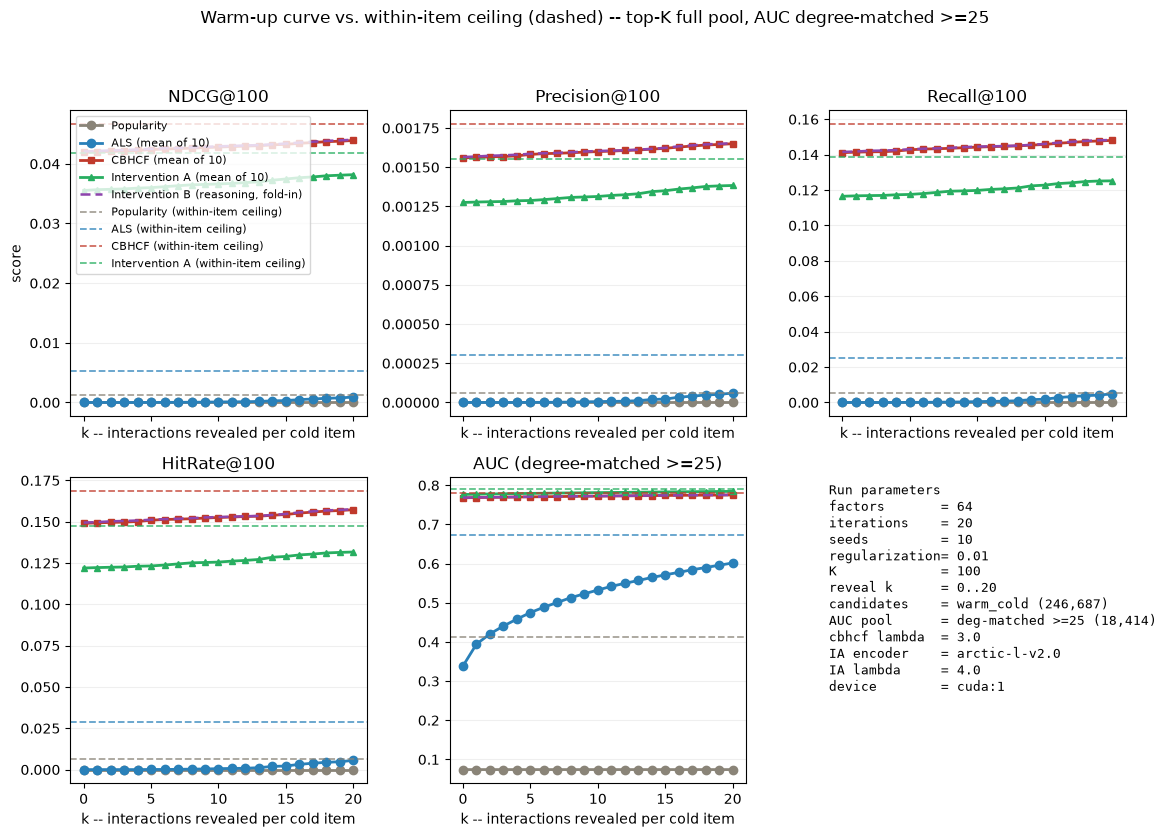

In [13]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS)):
    als_mean = np.array(als_curve[metric]["mean"])
    als_std = np.array(als_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    if RUN_POP:
        ax.plot(K_LEVELS, pop_curve[metric]["mean"], marker="o", markersize=6, linewidth=2,
                color="#8A8478", label=show_label("Popularity"))
    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    if RUN_CBHCF:
        cb_mean = np.array(cbhcf_curve[metric]["mean"]); cb_std = np.array(cbhcf_curve[metric]["std"])
        ax.plot(K_LEVELS, cb_mean, marker="s", markersize=5, linewidth=2,
                color="#c0392b", label=show_label(f"CBHCF (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, cb_mean - cb_std, cb_mean + cb_std, color="#c0392b", alpha=0.15, linewidth=0)
    if RUN_IA:
        ia_mean = np.array(ia_curve[metric]["mean"]); ia_std = np.array(ia_curve[metric]["std"])
        ax.plot(K_LEVELS, ia_mean, marker="^", markersize=5, linewidth=2,
                color="#27ae60", label=show_label(f"Intervention A (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, ia_mean - ia_std, ia_mean + ia_std, color="#27ae60", alpha=0.15, linewidth=0)
    if RUN_IB:
        # Same CBHCF models, same content half -- only the fold-in input differs, so this is drawn
        # dashed to read as a variant of the red CBHCF curve rather than as a separate method.
        # Only the LLM arm appears here; its control has its own figure below, because a control is
        # not a method and does not belong in a comparison of methods.
        ax.plot(K_LEVELS, ib_curves[IB_MAIN_ARM][metric]["mean"], linestyle=(0, (4, 2)),
                linewidth=1.8, color="#8e44ad",
                label=show_label(f"Intervention B ({IB_MAIN_ARM}, fold-in)"))
    if RUN_POP:
        ax.axhline(pop_ref["mean"][metric], color="#8A8478", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Popularity (within-item ceiling)"))
    ax.axhline(als_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))
    if RUN_CBHCF:
        ax.axhline(cbhcf_ref["mean"][metric], color="#c0392b", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("CBHCF (within-item ceiling)"))
    if RUN_IA:
        ax.axhline(ia_ref["mean"][metric], color="#27ae60", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Intervention A (within-item ceiling)"))

    ax.set_title("AUC (degree-matched >=25)" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", f"deg-matched >=25 ({len(seed_models[0]._auc_candidate_ids):,})"),
           ("cbhcf lambda", CBHCF_LAMBDA if RUN_CBHCF else "off"),
           ("IA encoder", IA_CFG["model_key"] if RUN_IA else "off"),
           ("IA lambda", IA_CFG["content_weight"] if RUN_IA else "off"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Warm-up curve vs. within-item ceiling (dashed) -- top-K full pool, AUC degree-matched >=25", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_a.png", dpi=120, bbox_inches="tight")
print("Saved Mode A warm-up curve to warmup_curve_mode_a.png")

### 9a-ii. Intervention B against its control

The figure above answers "how does Intervention B compare to the other methods". This one
answers the question that actually decides whether the LLM did anything: **how much of that gap
survives when the same number of synthetic interactions is chosen at random from the same
candidate pool?**

Plotted as a **difference from CBHCF**, not as raw curves. Every arm here shares one content
half, one collaborative half and one evaluation path, so the absolute curves sit within ~0.0002
of each other and overlap into a single line at any sensible axis scale — the raw view would
hide precisely what it is meant to show. Against the CBHCF baseline:

- the **grey control** is what injecting *N interactions per cold item* buys, whoever picks them
- the **gap between the two lines** is what the LLM's ordering buys on top of that

Both arms inject exactly the same count from exactly the same pool, so nothing else can explain
the difference between them.

Saved the control comparison to warmup_curve_intervention_b_control.png
CPU times: user 654 ms, sys: 45.1 ms, total: 699 ms
Wall time: 699 ms


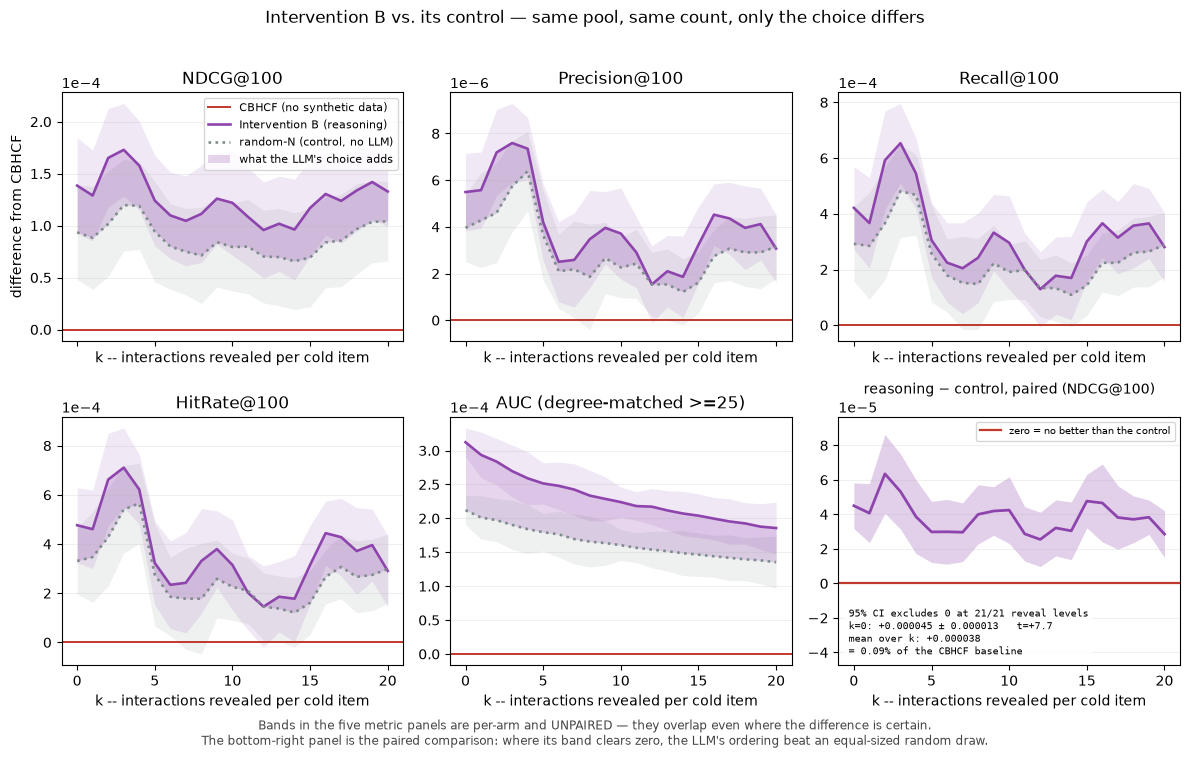

In [14]:
%%time
if RUN_IB and len(IB_ARMS) > 1:
    figc, axc = plt.subplots(2, 3, figsize=(12, 7), sharex="col")
    axc = axc.flatten()
    _IB_STYLE = {"reasoning": ("#8e44ad", "-", "Intervention B (reasoning)"),
                 "direct": ("#2980b9", "-", "Intervention B (direct)"),
                 "direct_cal": ("#16a085", "-", "Intervention B (calibrated)"),
                 "random": ("#7f8c8d", ":", "random-N (control, no LLM)"),
                 "popularity": ("#e67e22", ":", "popularity-N (control, no LLM)")}

    _n = len(cbhcf_models)
    _t95 = 2.262 if _n == 10 else 1.96          # two-sided 95%, 9 d.f.

    for j, (ax, metric) in enumerate(zip(axc, METRICS)):
        show = (lambda t: t) if j == 0 else (lambda t: None)
        base = np.array(cbhcf_curve[metric]["mean"])
        ax.axhline(0.0, color="#c0392b", linewidth=1.4, label=show("CBHCF (no synthetic data)"))
        _mean_of = {}
        for _arm in IB_ARMS:
            _c, _ls, _lbl = _IB_STYLE.get(_arm, ("#555555", "-", f"IB {_arm}"))
            _m = np.array(ib_curves[_arm][metric]["mean"]) - base
            _mean_of[_arm] = _m
            # Band = 95% CI of this arm's own mean curve across seeds (t * sd / sqrt(n)), NOT the
            # raw seed spread -- the curve plotted is a mean, so the interval belongs to the mean.
            # These are UNPAIRED and will overlap even where the paired test is decisive; the
            # bottom-right panel is what answers whether the gap is real.
            _ci = _t95 * np.array(ib_curves[_arm][metric]["std"]) / np.sqrt(_n)
            ax.plot(K_LEVELS, _m, linestyle=_ls, linewidth=1.9, color=_c, label=show(_lbl))
            ax.fill_between(K_LEVELS, _m - _ci, _m + _ci, color=_c, alpha=0.12, linewidth=0)
        # Shade the gap between the arm and its control -- that area IS the LLM's contribution,
        # and it is the quantity the eye should be drawn to rather than either curve's height.
        if IB_MAIN_ARM in _mean_of and "random" in _mean_of:
            ax.fill_between(K_LEVELS, _mean_of["random"], _mean_of[IB_MAIN_ARM],
                            color="#8e44ad", alpha=0.22, linewidth=0,
                            label=show("what the LLM's choice adds"))
        ax.set_title("AUC (degree-matched >=25)" if metric == "AUC" else f"{metric}@{K}")
        ax.set_xlabel("k -- interactions revealed per cold item")
        ax.grid(axis="y", alpha=0.2)
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    axc[0].set_ylabel("difference from CBHCF")
    axc[0].legend(fontsize=8, loc="best")

    # The decisive comparison gets its own panel, plotted rather than tabulated. The five panels
    # above show each arm against CBHCF with UNPAIRED bands, which overlap even when the gap is
    # certain -- reading "overlapping bands" as "no difference" is the single most likely
    # misinterpretation of this figure, and this panel is the answer to it.
    #
    # Paired because both arms were swept over the SAME models: the per-seed difference cancels the
    # common-mode ALS initialisation that dominates each arm's own spread. On these curves the
    # paired interval is roughly an order of magnitude tighter than an unpaired one.
    _pair = np.array([np.array(a["NDCG"]["mean"]) - np.array(b["NDCG"]["mean"])
                      for a, b in zip(ib_seed_curves[IB_MAIN_ARM], ib_seed_curves["random"])])
    _pm = _pair.mean(axis=0)
    _pci = _t95 * _pair.std(axis=0, ddof=1) / np.sqrt(_n)

    ax6 = axc[5]
    ax6.axhline(0.0, color="#c0392b", linewidth=1.6,
                label="zero = no better than the control")
    ax6.plot(K_LEVELS, _pm, color="#8e44ad", linewidth=2.0)
    ax6.fill_between(K_LEVELS, _pm - _pci, _pm + _pci, color="#8e44ad", alpha=0.25, linewidth=0)
    ax6.set_title(f"{IB_MAIN_ARM} − control, paired (NDCG@{K})", fontsize=10)
    ax6.set_xlabel("k -- interactions revealed per cold item")
    ax6.grid(axis="y", alpha=0.2)
    ax6.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    # Zero must sit clearly INSIDE the panel with room beneath it -- the whole point of this panel
    # is the visible gap between the band and zero, and a zero line pinned to the axis edge (or
    # hidden under the annotation) does not show that. Extra headroom below leaves the text clear.
    _lo, _hi = float((_pm - _pci).min()), float((_pm + _pci).max())
    _span = max(_hi - min(_lo, 0.0), 1e-12)
    ax6.set_ylim(min(_lo, 0.0) - 0.55 * _span, _hi + 0.12 * _span)
    ax6.legend(fontsize=7.5, loc="upper right")

    _excl = int(np.sum((_pm - _pci) > 0))          # k where the interval clears zero
    _d0, _sd0 = _pair[:, 0].mean(), _pair[:, 0].std(ddof=1)
    _t0 = _d0 / (_sd0 / np.sqrt(_n)) if _sd0 > 0 else float("nan")
    ax6.text(0.03, 0.03,
             f"95% CI excludes 0 at {_excl}/{len(K_LEVELS)} reveal levels\n"
             f"k=0: {_d0:+.6f} ± {_t95 * _sd0 / np.sqrt(_n):.6f}   t={_t0:+.1f}\n"
             f"mean over k: {float(_pm.mean()):+.6f}\n"
             f"= {100 * float(_pm.mean()) / float(np.mean(cbhcf_curve['NDCG']['mean'])):.2f}% "
             f"of the CBHCF baseline",
             transform=ax6.transAxes, family="monospace", fontsize=7.5, va="bottom",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, linewidth=0))

    figc.text(0.5, -0.03,
              "Bands in the five metric panels are per-arm and UNPAIRED — they overlap even where "
              "the difference is certain.\nThe bottom-right panel is the paired comparison: where "
              "its band clears zero, the LLM's ordering beat an equal-sized random draw.",
              ha="center", fontsize=8.5, color="#444444")

    figc.suptitle("Intervention B vs. its control — same pool, same count, only the choice differs",
                  y=1.02)
    plt.tight_layout()
    plt.savefig("warmup_curve_intervention_b_control.png", dpi=120, bbox_inches="tight")
    print("Saved the control comparison to warmup_curve_intervention_b_control.png")
else:
    print("Intervention B control figure skipped (needs RUN_IB and at least two IB_ARMS).")

## 9b. Head / torso / tail breakdown (secondary)

Splits the cold items into equal-count degree terciles (by TOTAL interactions) and reports, at the
within-item ceiling per bucket: the **degree range** each bucket spans, **HitRate@K** (fraction of
that bucket's held-out interactions retrieved into top-K) and **NDCG@K** (its rank-discounted
version — are head items not just *hit* more often but ranked *higher*?). The mainstream,
low-friction way to surface popularity / long-tail effects (Steck 2011 popularity-stratified
evaluation; the head/torso/tail breakdown standard in long-tail recsys), complementary to the
degree-matched AUC. Reading it: even fully warm, do low-degree (tail) cold items retrieve worse
than head? Buckets are equal-count in items, so each holds ~n_cold/3 items and ~5x that many
held-out interactions (the fixed last-5 test). The **Popularity floor** is shown per bucket
alongside ALS, so you can see whether ALS's edge over popularity is uniform across degree or (as
expected) concentrated in the head, where raw counts are high.

free VRAM: 14.8 GB   chunks: ALS 1,536, CBHCF 1,024, IA 1,024
Head/torso/tail at the within-item ceiling (equal-count degree terciles, K=100):
  bucket    degree range  median  items  ALS HitR  ALS NDCG   CB HitR   CB NDCG   IA HitR   IA NDCG  Pop HitR  Pop NDCG
  tail             25-32      27    909    0.0101    0.0020    0.1706    0.0520    0.1498    0.0463    0.0000    0.0000
  torso            32-49      38    909    0.0092    0.0017    0.1590    0.0452    0.1338    0.0398    0.0000    0.0000
  head           49-1759      75    909    0.0625    0.0128    0.1537    0.0406    0.1395    0.0369    0.0172    0.0035
Saved head/torso/tail breakdown to warmup_tail_breakdown.png
CPU times: user 10.5 s, sys: 6.38 s, total: 16.9 s
Wall time: 17.1 s


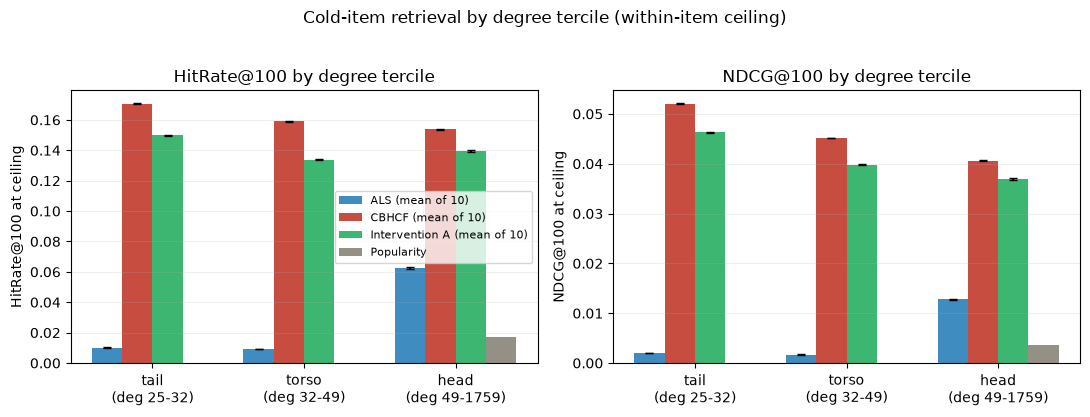

In [15]:
%%time
# ALS's chunk was auto-computed by prepare_gpu_recommend(vram_budget_gb=8.0) when the card was
# empty -- it still asks for an ~8 GB score block and OOMs. Re-budget for a card carrying ONE arm's
# ~8.3 GB content block. (With `activate()` swapping arms in and out, only one is ever resident, so
# this budget is the same whether or not Intervention A is running -- which is the point.)
import torch
torch.cuda.empty_cache()
print(f"free VRAM: {torch.cuda.mem_get_info(torch.device(DEVICE))[0] / 1e9:.1f} GB   "
      f"chunks: ALS {seed_models[0]._gpu_chunk:,}"
      + (f", CBHCF {cbhcf_models[0]._gpu_chunk:,}" if RUN_CBHCF else "")
      + (f", IA {ia_models[0]._gpu_chunk:,}" if RUN_IA else ""))

item_bucket, bucket_labels, bucket_info = ev.cold_item_degree_buckets(dataset, n_buckets=3)
strata = ev.ceiling_metrics_by_bucket(seed_models, dataset, item_bucket, K=K, n_buckets=3)
torch.cuda.empty_cache()
# Popularity floor per bucket -- PopularityModel has fold_in_ceiling/recommend, so the same call
# works. Reveals whether ALS's edge over popularity is uniform across degree or head-concentrated.
pop_strata = ev.ceiling_metrics_by_bucket([pop_model], dataset, item_bucket, K=K, n_buckets=3) if RUN_POP else None
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_strata = ev.ceiling_metrics_by_bucket(cbhcf_models, dataset, item_bucket, K=K, n_buckets=3) if RUN_CBHCF else None
torch.cuda.empty_cache()
if RUN_IA:
    activate(ia_models)
ia_strata = ev.ceiling_metrics_by_bucket(ia_models, dataset, item_bucket, K=K, n_buckets=3) if RUN_IA else None
torch.cuda.empty_cache()

print(f"Head/torso/tail at the within-item ceiling (equal-count degree terciles, K={K}):")
hdr = f"  {'bucket':<7}{'degree range':>15}{'median':>8}{'items':>7}{'ALS HitR':>10}{'ALS NDCG':>10}"
if RUN_CBHCF:
    hdr += f"{'CB HitR':>10}{'CB NDCG':>10}"
if RUN_IA:
    hdr += f"{'IA HitR':>10}{'IA NDCG':>10}"
if RUN_POP:
    hdr += f"{'Pop HitR':>10}{'Pop NDCG':>10}"
print(hdr)
for b, lab in enumerate(bucket_labels):
    bi, s = bucket_info[b], strata[b]
    rng = f"{bi['deg_min']}-{bi['deg_max']}"
    row = f"  {lab:<7}{rng:>15}{bi['deg_median']:>8}{bi['n_items']:>7,}{s['hitrate']:>10.4f}{s['ndcg']:>10.4f}"
    if RUN_CBHCF:
        cs = cbhcf_strata[b]
        row += f"{cs['hitrate']:>10.4f}{cs['ndcg']:>10.4f}"
    if RUN_IA:
        ias = ia_strata[b]
        row += f"{ias['hitrate']:>10.4f}{ias['ndcg']:>10.4f}"
    if RUN_POP:
        ps = pop_strata[b]
        row += f"{ps['hitrate']:>10.4f}{ps['ndcg']:>10.4f}"
    print(row)

# Two panels (HitRate, NDCG); ALS vs Popularity per degree tercile.
fig, (axh, axn) = plt.subplots(1, 2, figsize=(11, 4))
xs = np.arange(len(bucket_labels)); w = 0.38
xtl = [f"{bucket_labels[b]}\n(deg {bucket_info[b]['deg_min']}-{bucket_info[b]['deg_max']})"
       for b in range(len(bucket_labels))]
_nbars = 1 + int(RUN_POP) + int(RUN_CBHCF) + int(RUN_IA)
w = 0.8 / _nbars
for ax, metric, mlabel in [(axh, "hitrate", f"HitRate@{K}"), (axn, "ndcg", f"NDCG@{K}")]:
    _slot = 0
    ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [strata[b][metric] for b in range(len(bucket_labels))], w,
           yerr=[strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
           color="#2980b9", alpha=0.9, label=f"ALS (mean of {N_SEEDS})")
    if RUN_CBHCF:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [cbhcf_strata[b][metric] for b in range(len(bucket_labels))], w,
               yerr=[cbhcf_strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
               color="#c0392b", alpha=0.9, label=f"CBHCF (mean of {N_SEEDS})")
    if RUN_IA:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [ia_strata[b][metric] for b in range(len(bucket_labels))], w,
               yerr=[ia_strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
               color="#27ae60", alpha=0.9, label=f"Intervention A (mean of {N_SEEDS})")
    if RUN_POP:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [pop_strata[b][metric] for b in range(len(bucket_labels))], w,
               color="#8A8478", alpha=0.9, label="Popularity")
    ax.set_xticks(xs); ax.set_xticklabels(xtl)
    ax.set_ylabel(f"{mlabel} at ceiling"); ax.set_title(f"{mlabel} by degree tercile")
    ax.grid(axis="y", alpha=0.2)
axh.legend(fontsize=8)
fig.suptitle("Cold-item retrieval by degree tercile (within-item ceiling)", y=1.03)
plt.tight_layout()
plt.savefig("warmup_tail_breakdown.png", dpi=120, bbox_inches="tight")
print("Saved head/torso/tail breakdown to warmup_tail_breakdown.png")

# Log the head/torso/tail ceiling breakdown to the (still-open) ALS run as summary values.
for b, lab in enumerate(bucket_labels):
    als_run.summary[f"tail/{lab}/HitRate"] = strata[b]["hitrate"]
    als_run.summary[f"tail/{lab}/NDCG"] = strata[b]["ndcg"]
    if RUN_CBHCF:
        cbhcf_run.summary[f"tail/{lab}/HitRate"] = cbhcf_strata[b]["hitrate"]
        cbhcf_run.summary[f"tail/{lab}/NDCG"] = cbhcf_strata[b]["ndcg"]
    if RUN_IA:
        ia_run.summary[f"tail/{lab}/HitRate"] = ia_strata[b]["hitrate"]
        ia_run.summary[f"tail/{lab}/NDCG"] = ia_strata[b]["ndcg"]

## 9c. Provider exposure equity (secondary)

Section 9 asks an **item-side** question: did the cold item become retrievable? This asks the
**provider-side** companion: whose items actually get recommended, and does an intervention that
makes cold items retrievable also move exposure toward the providers of those items — or does it
concentrate attention on providers who were already well represented?

Provider is the item's **canonical creator** (`content.canonical_creator`: `author_name`, falling
back to `store`, with the role-suffix and storefront cleaning the TF-IDF `creator` block already
applies). Deliberately the *same* partition the content models see — building a separate one from
raw `author_name` would group the catalogue differently from the way the model groups it, and the
fairness number would then describe a partition the model never had access to.

**Read the between-arm difference, not the absolute level.** All three arms wrap the same ten ALS
fits and the same frozen user factors, so a difference at matched `k` is attributable to the item
representation and nothing else — the logic the rest of the notebook rests on. The absolute Gini
of an Amazon Books recommender is mostly a fact about the catalogue.

Four decisions that used to be implicit; reasoning in `design_documents/06-provider-equity.md`:

- **The eval-user population, because the hybrids cannot be scored on any other.** Exposure is a
  count of impressions across the surface you serve, so the whole population is what we would
  want — and ALS and Popularity can be scored that way. CBHCF and Intervention A cannot: their
  content half is a precomputed user × item block (`cbhcf.build_content_cache`), 6.1 GB at fp16
  for 12,382 users, hence ~189 GB per arm for all 384,339. That is not a budget problem; a block
  that size could not be swapped onto the card at all. So every arm is measured on the set all
  arms can be scored on, because measuring arms over different populations would make the
  between-arm difference — the entire point of this section — uninterpretable.
  - Two consequences, both stated rather than hidden. The eval users are exactly those holding a
    held-out *cold* interaction, so they over-represent cold-affine taste and will flatter
    cold-item providers. And the set is thin: ~137k providers against 12,382×K impressions is ~9
    each, so absolute Gini partly measures small-sample zeros. (The universe is the
    CANDIDATE POOL's providers -- ~87k over 246,687 warm+cold items -- not the whole
    catalogue's ~137k, so it is ~14 impressions per provider, not ~9.)
  - The **population sensitivity** table below quantifies both, by scoring ALS and Popularity
    each way. Popularity is the control: its ranking is user-independent, so its delta isolates
    "which users" with personalisation held out, and the gap to ALS's delta is the part caused by
    personalisation meeting cold-affine taste.
- **Position-discounted exposure.** Uniform-over-top-100 is not the absence of a user model, it is
  the claim that rank 100 is worth as much as rank 1. `log` is the headline *because NDCG uses
  exactly that discount*, so the accuracy and equity curves describe the same hypothetical user;
  uniform and RBP sit beside it as the sensitivity band.
- **Three reference shares**: catalog share over all items, catalog share over cold items only,
  and merit share from held-out relevance. Numerator and denominator always cover the same
  population.
- **Six summaries of the ratio distribution**, because an unweighted mean over a heavy tail of
  one-book authors is dominated by noise, and because ratios are multiplicative — 4× and 0.25×
  average to 2.1×, not 1.

Gini on discounted exposure is *mechanically* higher than on uniform exposure: the mass is
concentrated before its concentration is measured. Compare arms within a discount, never across.

In [16]:
%%time
# ---- setup: provider map, population, GPU chunk ------------------------------------------------
from recsys import equity_metrics as eq

EQUITY_DISCOUNT = eq.HEADLINE_DISCOUNT          # "log" -- NDCG's own discount; see the prose above

# THE USER POPULATION IS NOT A FREE CHOICE. Exposure is a property of the whole recommendation
# surface, so the whole population is what we would want to measure -- but CBHCF and Intervention A
# score their content half from a PRECOMPUTED user x item block (cbhcf.build_content_cache), and
# that block only covers the users it was built for. At Books scale it is 12,382 users x 246,687
# warm items = 6.1 GB at fp16; the full 384,339-user population would be ~189 GB per arm, and there
# are two arms. Rebuilding it wider is not a tuning knob, it is not possible.
#
# So every arm is measured over the users ALL arms can score -- the eval-user set. Measuring ALS
# over 384k and the hybrids over 12k would make the between-arm difference, which is the entire
# point of this section, uninterpretable. `population_sensitivity` below quantifies what the
# restriction costs, using ALS, the one arm that can be scored both ways.
EQUITY_USERS = eq.common_covered_users(seed_models, cbhcf_models, ia_models)
if EQUITY_USERS is None:
    EQUITY_USERS = np.arange(dataset.n_users)   # no hybrid arms this run -> nothing restricts us
RUN_POP_EQUITY = True    # Popularity has no warm cache, so it takes eq.sweep_provider_equity's
                         # generic path. MEASURED at Books scale rather than assumed: its
                         # recommend() is vectorized over a global top-M, so a full-population
                         # level costs 2.3 s at max user degree ~500 and 13.4 s at ~5,000 --
                         # 0.8-4.7 min for the 21 levels. It is also the most interpretable
                         # comparator in this section: Popularity serves every user the same list,
                         # so its Gini is the concentration CEILING, and "ALS = 0.87" means
                         # nothing without it.
RUN_IB_EQUITY = RUN_IB   # IB reuses the CBHCF models against SyntheticAugmentedDataset, so each
                         # arm is another full pass.

# Every arm that is NOT measured records why, so a missing line in the table or figure below can
# never be read as a zero. Printed at the end and persisted with the results in Section 11.
equity_skipped = {}

# The provider map is deliberately NOT pickle-cached. It is derived from content.py's tokenizer,
# and cache_pickle keys on data fingerprints that cannot see a code change -- exactly how the
# creator-suffix fix nearly resurfaced stale content blocks and a stale tuning grid earlier in this
# project. ~1 min against an hour-long run is the right price for removing that failure mode.
provider_map, provider_stats = eq.load_provider_map(
    "../data/filtered/books_meta_5core_common.parquet", dataset,
    pool_items=seed_models[0]._candidate_ids)

# NOT optional. If the metadata ids ever stop matching dataset.index_to_item, every item maps to
# UNKNOWN and a one-provider catalogue reports Gini 0.0 and equity ratio 1.0 -- "perfect equality",
# the most dangerous possible failure mode for a fairness metric, and it does not raise on its own.
assert provider_stats["unattributed_frac"] < 0.02, (
    f"provider map is {provider_stats['unattributed_frac']:.1%} UNKNOWN -- id format mismatch? "
    f"Expected ~0.5% once the author_name -> store fallback is working.")
print(f"providers: {provider_map.n_providers:,} over {provider_map.n_pool_items:,} candidate items "
      f"({provider_stats['unattributed_frac']:.2%} unattributed, "
      f"{provider_stats['multi_creator_frac']:.2%} of items have >1 creator entity -- the primary "
      f"one is used)")

# The warm cache here covers ALL users, not the 12k eval users, so each score block is ~31x the one
# the sweeps above sized their chunks for. Shrink the chunk for this section and restore it after,
# rather than discovering the difference as an OOM mid-pass.
_EQUITY_CHUNK = 512
_saved_chunks = {id(m): m._gpu_chunk for grp in (seed_models, cbhcf_models or [], ia_models or [])
                 for m in grp}
for grp in (seed_models, cbhcf_models or [], ia_models or []):
    for m in grp:
        m._gpu_chunk = _EQUITY_CHUNK
torch.cuda.empty_cache()
print(f"equity pass: {len(EQUITY_USERS):,} users "
      f"({len(EQUITY_USERS) / dataset.n_users:.1%} of the population -- the set every arm can be "
      f"scored on), {_EQUITY_CHUNK} users/chunk, free VRAM "
      f"{torch.cuda.mem_get_info(torch.device(DEVICE))[0] / 1e9:.1f} GB")

providers: 86,791 over 246,687 candidate items (0.47% unattributed, 4.37% of items have >1 creator entity -- the primary one is used)
equity pass: 12,382 users (3.2% of the population -- the set every arm can be scored on), 512 users/chunk, free VRAM 14.8 GB
CPU times: user 1.97 s, sys: 148 ms, total: 2.12 s
Wall time: 2.12 s


In [17]:
%%time
# ---- the arms -----------------------------------------------------------------------------------
equity_curves, equity_ceiling, equity_acc = {}, {}, {}
# Why an arm has no ceiling of its own. Printed with the table, and persisted: a bare
# `nan` that the reader cannot distinguish from a computed value is the same defect as a
# missing arm reading as a zero.
equity_ceiling_note = {}


def _equity_arm(label, models, ds=dataset, activate_group=None):
    """One arm through the full-population pass plus its within-item ceiling. The accumulator is
    kept, not just its curves: it also holds the per-provider exposure shares across seeds at the
    last reveal level, which is the ranking-stability readout below -- getting that from a second
    pass would mean rebuilding every seed's warm cache for nothing."""
    if activate_group is not None:
        activate(activate_group)
    acc = eq.sweep_provider_equity_full(models, ds, provider_map, K_LEVELS, K=K,
                                        users=EQUITY_USERS, accumulator=True)
    equity_acc[label], equity_curves[label] = acc, acc.curves()
    equity_ceiling[label] = eq.ceiling_equity(models, ds, provider_map, K=K, users=EQUITY_USERS)
    torch.cuda.empty_cache()


_equity_arm("ALS", seed_models)
if RUN_POP_EQUITY:
    # Generic path -- no warm cache on PopularityModel. Not pickle-cached, unlike pop_ref/pop_k0/
    # pop_curve above: those are stable metrics on a fixed Dataset, whereas equity_metrics is new
    # and its semantics are still moving, and cache_pickle keys on data fingerprints that cannot
    # see that. A few minutes does not earn that risk. EQUITY_METRICS_VERSION exists to key a
    # cache on once the definitions settle.
    equity_curves["Popularity"] = eq.sweep_provider_equity(
        [pop_model], dataset, provider_map, K_LEVELS, K=K, users=EQUITY_USERS)
    equity_ceiling["Popularity"] = eq.ceiling_equity_generic(
        [pop_model], dataset, provider_map, K=K, users=EQUITY_USERS)
else:
    equity_skipped["Popularity"] = "RUN_POP_EQUITY is False"
if RUN_CBHCF:
    _equity_arm("CBHCF", cbhcf_models, activate_group=cbhcf_models)
else:
    equity_skipped["CBHCF"] = "RUN_CBHCF is False"
if RUN_IA:
    _equity_arm("Intervention A", ia_models, activate_group=ia_models)
else:
    equity_skipped["Intervention A"] = "RUN_IA is False"
if not RUN_IB_EQUITY:
    equity_skipped.update({f"IB-{a}": "RUN_IB_EQUITY is False" for a in IB_ARMS} if RUN_IB
                          else {"IB": "RUN_IB is False (no synthetic export for this split)"})
if RUN_IB_EQUITY:
    # Same CBHCF models, only the fold-in input differs -- exactly as in Section 9.
    activate(cbhcf_models)
    for arm in IB_ARMS:
        _mats = _ib.get("seed_matrices", {}).get(arm)
        _per_seed = []
        for _si, _m in enumerate(cbhcf_models):
            _aug = coldllm.SyntheticAugmentedDataset(
                dataset, _mats[_si] if _mats else _ib["matrices"][arm], tag=f"ib|{arm}|s{_si}")
            _per_seed.append(eq.sweep_provider_equity_full(
                [_m], _aug, provider_map, K_LEVELS, K=K, users=EQUITY_USERS, verbose=False))
        # Average the per-seed curves, matching how Section 9 builds ib_curves.
        equity_curves[f"IB-{arm}"] = {
            d: {met: {"mean": np.mean([c[d][met]["mean"] for c in _per_seed], axis=0),
                      "std": np.std([c[d][met]["mean"] for c in _per_seed], axis=0)}
                for met in _per_seed[0][d]}
            for d in _per_seed[0]}
        # `SyntheticAugmentedDataset` overrides `revealed_item_users_at_k` -- the REVEAL path --
        # and deliberately not `ceiling_item_users`. So at the ceiling every cold item is folded in
        # from its real pre-test history and Intervention B is byte-identical to CBHCF. Borrow it
        # rather than spend a pass recomputing the same number, and say that is what happened.
        if "CBHCF" in equity_ceiling:
            equity_ceiling[f"IB-{arm}"] = equity_ceiling["CBHCF"]
            equity_ceiling_note[f"IB-{arm}"] = ("shares CBHCF's ceiling by construction: the "
                                                "synthetic wrapper overrides the reveal path only")
for grp in (seed_models, cbhcf_models or [], ia_models or []):
    for m in grp:
        m._gpu_chunk = _saved_chunks[id(m)]
torch.cuda.empty_cache()

[sweep_provider_equity_full] users=12,382 providers=86,791 discounts=7  setup=0.4s  warm=2.6s  foldin=2.8s  recommend=3.5s  equity=17.1s  total=26.4s
[ceiling_equity] users=12,382 seeds=10  2.6s
[sweep_provider_equity_full] users=12,382 providers=86,791 discounts=7  setup=0.4s  warm=3.9s  foldin=2.9s  recommend=7.6s  equity=22.3s  total=37.1s
[ceiling_equity] users=12,382 seeds=10  4.6s
[sweep_provider_equity_full] users=12,382 providers=86,791 discounts=7  setup=0.4s  warm=3.8s  foldin=2.8s  recommend=7.6s  equity=22.0s  total=36.6s
[ceiling_equity] users=12,382 seeds=10  4.6s
CPU times: user 3min 21s, sys: 31.4 s, total: 3min 52s
Wall time: 3min 52s


In [18]:
# ---- readout -----------------------------------------------------------------------------------
_d = EQUITY_DISCOUNT
_lastk = len(K_LEVELS) - 1
print(f"\nProvider exposure equity ({_d} discount, K={K}, "
      f"{dataset.n_users if EQUITY_USERS is None else len(EQUITY_USERS):,} users, "
      f"equity_metrics v{eq.EQUITY_METRICS_VERSION}):")
print(f"  {'arm':<16}{'Gini k=0':>10}{'Gini k=20':>11}{'Gini ceil':>11}"
      f"{'cold share k=0':>16}{'cold share k=20':>17}{'cold ratio k=20':>17}{'top1% k=20':>12}")
for label, cur in equity_curves.items():
    c = cur[_d]
    ceil = equity_ceiling.get(label)
    _ceil_txt = f"{ceil[_d]['gini']['mean'][0]:>11.4f}" if ceil else f"{'--':>11}"
    print(f"  {label:<16}{c['gini']['mean'][0]:>10.4f}{c['gini']['mean'][_lastk]:>11.4f}"
          f"{_ceil_txt}"
          f"{c['cold_exposure_share']['mean'][0]:>16.5f}"
          f"{c['cold_exposure_share']['mean'][_lastk]:>17.5f}"
          f"{c['cold_ratio.exposure_weighted_mean']['mean'][_lastk]:>17.3f}"
          f"{c['top1pct_share']['mean'][_lastk]:>12.4f}")
if equity_ceiling_note:
    for _l, _why in equity_ceiling_note.items():
        print(f"    {_l}: {_why}")
_no_ceil = [l for l in equity_curves if l not in equity_ceiling]
if _no_ceil:
    print(f"    '--' = no within-item ceiling computed for: {', '.join(_no_ceil)}")
print("    cold ratio is unstable where cold exposure is near zero -- ALS holds ~0.3% of")
print("    impressions on cold items, so its ratio rests on very few providers.")


Provider exposure equity (log discount, K=100, 12,382 users, equity_metrics v1):
  arm               Gini k=0  Gini k=20  Gini ceil  cold share k=0  cold share k=20  cold ratio k=20  top1% k=20
  ALS                 0.9950     0.9950     0.9951         0.00000          0.00264           42.334      0.9407
  Popularity          0.9994     0.9994     0.9994         0.00000          0.00000              nan      1.0000
  CBHCF               0.8784     0.8785     0.8786         0.02336          0.02504            2.183      0.5603
  Intervention A      0.8641     0.8641     0.8645         0.01835          0.02061            3.862      0.4939
  IB-reasoning        0.8784     0.8785     0.8786         0.02358          0.02532            2.203      0.5603
  IB-random           0.8784     0.8785     0.8786         0.02358          0.02531            2.204      0.5603
    IB-reasoning: shares CBHCF's ceiling by construction: the synthetic wrapper overrides the reveal path only
    IB-random: s

In [19]:
%%time
# ---- how much does restricting the population cost? ---------------------------------------------
# The eval-user set is not a random sample: it is exactly the users holding a held-out COLD
# interaction, so it over-represents users with cold-affine taste and will flatter cold-item
# providers. It is also thin -- ~12k x K impressions over ~137k providers is ~9 each, so a Gini
# over it partly measures small-sample zeros. Neither objection can be removed (see the block at
# the top of this cell), but ALS can be scored over the whole population, so the size of the bias
# can be MEASURED on one arm and quoted as a limitation rather than left as a worry.
population_sensitivity = {}
_SENS_K = [K_LEVELS[0], K_LEVELS[-1]]
if len(EQUITY_USERS) < dataset.n_users:
    _sens_full = {}
    for m in seed_models:
        m._gpu_chunk = _EQUITY_CHUNK
    _sens_full["ALS"] = eq.sweep_provider_equity_full(
        seed_models, dataset, provider_map, _SENS_K, K=K, users=None, verbose=True)
    for m in seed_models:
        m._gpu_chunk = _saved_chunks[id(m)]
    torch.cuda.empty_cache()
    # Popularity is the CONTROL for this comparison, not just a second data point. Its ranking is
    # user-independent -- everyone gets the same global top-M, differing only through the
    # already-liked filter -- so its delta isolates the effect of WHICH users are scored with
    # personalization held out. ALS's delta contains that same effect PLUS personalization meeting
    # the eval users' cold-affine taste. The GAP between the two deltas is that second part, which
    # is the bias we actually care about and could not otherwise separate.
    if RUN_POP_EQUITY:
        _sens_full["Popularity"] = eq.sweep_provider_equity(
            [pop_model], dataset, provider_map, _SENS_K, K=K, users=None)

    print(f"\nPopulation sensitivity -- eval users ({len(EQUITY_USERS):,}) vs all "
          f"({dataset.n_users:,}). Only ALS and Popularity can be scored both ways; the hybrids'\n"
          f"content block does not cover the population at all, so they have no full-population\n"
          f"counterpart to compare against.")
    print(f"  {'arm':<12}{'metric':<22}{'k':>4}{'eval users':>13}{'all users':>13}"
          f"{'delta':>11}{'rel':>9}")
    for _label, _full in _sens_full.items():
        _sub = equity_curves[_label][_d]
        population_sensitivity[_label] = {
            "gini_restricted": [_sub["gini"]["mean"][0], _sub["gini"]["mean"][_lastk]],
            "gini_full": list(_full[_d]["gini"]["mean"]),
            "cold_share_restricted": [_sub["cold_exposure_share"]["mean"][0],
                                      _sub["cold_exposure_share"]["mean"][_lastk]],
            "cold_share_full": list(_full[_d]["cold_exposure_share"]["mean"]),
        }
        for _name, _rk, _fk in (("Gini", "gini_restricted", "gini_full"),
                                ("cold exposure share", "cold_share_restricted", "cold_share_full")):
            for _j, _kk in enumerate(_SENS_K):
                _r = population_sensitivity[_label][_rk][_j]
                _f = population_sensitivity[_label][_fk][_j]
                _rel = (_f - _r) / _r * 100 if _r else float("nan")
                print(f"  {_label:<12}{_name:<22}{_kk:>4}{_r:>13.5f}{_f:>13.5f}"
                      f"{_f - _r:>+11.5f}{_rel:>+9.1f}%")
    population_sensitivity["n_users_restricted"] = int(len(EQUITY_USERS))
    population_sensitivity["n_users_full"] = int(dataset.n_users)
    population_sensitivity["k_levels"] = list(_SENS_K)
    population_sensitivity["merit_excluded_because"] = (
        "merit share is derived from the held-out set, i.e. from the eval users; dividing "
        "full-population exposure by it would mix populations (the D4 defect). "
        "ExposureAccumulator returns NaN merit stats for any run whose scored users are not "
        "exactly the merit users.")
    print("  Merit ratio is deliberately ABSENT from this table -- it is derived from the held-out")
    print("  set, so it has no full-population counterpart; the accumulator returns NaN for it there.")
    print()
    print("  READ THE RELATIVE COLUMN, NOT THE ABSOLUTE ONE. Gini here sits at 0.86-0.999, i.e. hard")
    print("  against its own ceiling, so a small absolute delta is largely SATURATION and is weak")
    print("  evidence that the populations agree. Cold exposure share has room to move and is the")
    print("  sensitive test: its relative shift is the size of the eval-user bias, and it is")
    print("  negative because the eval users -- who by definition hold a held-out COLD interaction")
    print("  -- are cold-affine and inflate cold exposure relative to the whole population.")
    print("  So: between-arm differences are valid; absolute Gini is safe to quote; absolute cold")
    print("  exposure share should be quoted as an eval-user figure carrying that relative bias.")

[sweep_provider_equity_full] users=384,339 providers=86,791 discounts=7  setup=0.0s  warm=33.9s  foldin=0.6s  recommend=14.9s  equity=8.4s  total=57.8s

Population sensitivity -- eval users (12,382) vs all (384,339). Only ALS and Popularity can be scored both ways; the hybrids'
content block does not cover the population at all, so they have no full-population
counterpart to compare against.
  arm         metric                   k   eval users    all users      delta      rel
  ALS         Gini                     0      0.99497      0.99480   -0.00016     -0.0%
  ALS         Gini                    20      0.99496      0.99480   -0.00016     -0.0%
  ALS         cold exposure share      0      0.00000      0.00000   +0.00000     +nan%
  ALS         cold exposure share     20      0.00264      0.00251   -0.00012     -4.6%
  Popularity  Gini                     0      0.99940      0.99940   +0.00000     +0.0%
  Popularity  Gini                    20      0.99940      0.99940   +0.00000 

In [20]:
# ---- diagnostics: merit availability, skipped arms, discount band, seed stability ---------------
_merit_ok = all(a.merit_available for a in equity_acc.values())
print(f"\nMerit ratio: {'available' if _merit_ok else 'NOT available'} for this run "
      f"(scored users {'==' if _merit_ok else '!='} the held-out/merit population).")

if equity_skipped:
    print("\nArms NOT measured -- absent from every table and figure in this section, which is why\n"
          "they are named here rather than simply missing:")
    for _a, _why in equity_skipped.items():
        print(f"  {_a:<16} {_why}")
else:
    print(f"\nAll arms measured: {', '.join(equity_curves)}.")

print(f"\nDiscount sensitivity -- Gini at k={K_LEVELS[_lastk]} (levels are NOT comparable across "
      f"discounts; concentrating the mass raises Gini by construction):")
print(f"  {'arm':<16}" + "".join(f"{d:>12}" for d in eq.DEFAULT_DISCOUNTS))
for label, cur in equity_curves.items():
    print(f"  {label:<16}" + "".join(f"{cur[d]['gini']['mean'][_lastk]:>12.4f}"
                                     for d in eq.DEFAULT_DISCOUNTS))

# Deterministic top-K turns a 1e-9 score difference into a ~60% attention gap, so some of the
# measured concentration is the serving rule rather than the model. Stable Gini across seeds with
# UNSTABLE per-provider shares means the concentration is real but who occupies the head is
# substantially arbitrary. Free: the accumulator already recorded per-provider shares per seed at
# the last reveal level. See the design doc's "Ranking stochasticity" section for why the
# principled fix -- a stochastic ranking policy -- is a different experiment.
print(f"\nHead-provider stability across the {N_SEEDS} ALS fits, at k={K_LEVELS[_lastk]} "
      f"(top 20 providers by mean exposure share):")
for label in ("ALS", "CBHCF", "Intervention A"):
    if label not in equity_acc:
        continue
    _sv = equity_acc[label].seed_variance(top_n=20)
    _gini_sd = equity_curves[label][_d]["gini"]["std"][_lastk]
    print(f"  {label:<16} gini sd across seeds {_gini_sd:.5f}   "
          f"per-provider share CV: median {np.nanmedian(_sv['cv']):.3f}  "
          f"max {np.nanmax(_sv['cv']):.3f}")


Merit ratio: available for this run (scored users == the held-out/merit population).

All arms measured: ALS, Popularity, CBHCF, Intervention A, IB-reasoning, IB-random.

Discount sensitivity -- Gini at k=20 (levels are NOT comparable across discounts; concentrating the mass raises Gini by construction):
  arm               uniform@10  uniform@20 uniform@100         log     rbp0.90     rbp0.80     rbp0.95
  ALS                   0.9991      0.9985      0.9941      0.9950      0.9984      0.9991      0.9973
  Popularity            0.9999      0.9998      0.9993      0.9994      0.9998      0.9999      0.9997
  CBHCF                 0.9564      0.9403      0.8689      0.8785      0.9384      0.9560      0.9136
  Intervention A        0.9466      0.9246      0.8545      0.8641      0.9246      0.9474      0.8978
  IB-reasoning          0.9564      0.9403      0.8690      0.8785      0.9384      0.9560      0.9137
  IB-random             0.9564      0.9403      0.8690      0.8785      0.9


Saved provider-equity curves to warmup_equity_mode_a.png


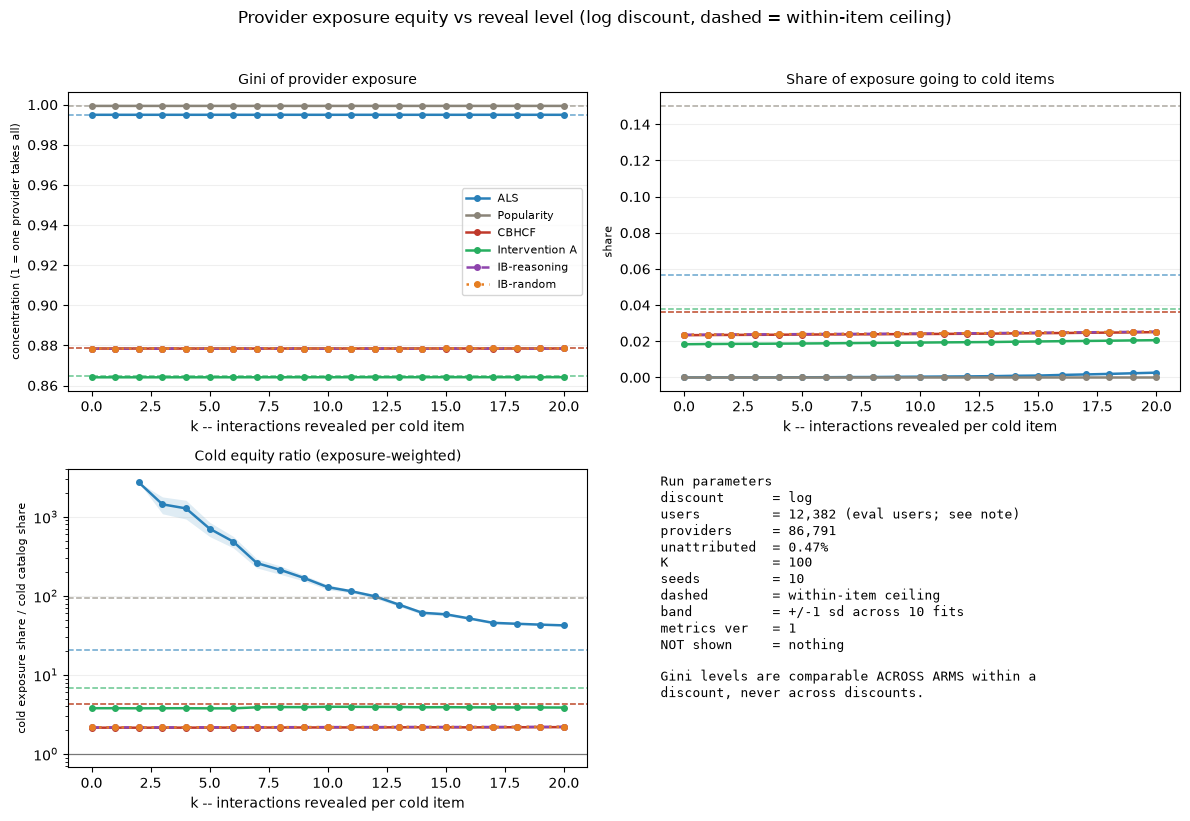

In [21]:
# ---- figure ------------------------------------------------------------------------------------
_COLOR = {"ALS": "#2980b9", "CBHCF": "#c0392b", "Intervention A": "#27ae60",
          "Popularity": "#8A8478"}
_STYLE = {}
# The two IB arms sit almost exactly on top of each other AND on CBHCF (they are the same models,
# differing only in fold-in input), so they need distinct dash patterns or the figure shows one
# line where there are three. That they overlap is the finding; it should be visibly the finding.
for _i, _a in enumerate(IB_ARMS if RUN_IB_EQUITY else []):
    _COLOR[f"IB-{_a}"] = ["#8e44ad", "#e67e22"][_i % 2]
    _STYLE[f"IB-{_a}"] = [(0, (4, 2)), (0, (1, 2))][_i % 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
_PANELS = [("gini", "Gini of provider exposure", "concentration (1 = one provider takes all)"),
           ("cold_exposure_share", "Share of exposure going to cold items", "share"),
           ("cold_ratio.exposure_weighted_mean",
            "Cold equity ratio (exposure-weighted)", "cold exposure share / cold catalog share")]
for ax, (metric, title, ylab) in zip(axes.flat, _PANELS):
    for label, cur in equity_curves.items():
        m = np.array(cur[EQUITY_DISCOUNT][metric]["mean"])
        s = np.array(cur[EQUITY_DISCOUNT][metric]["std"])
        ax.plot(K_LEVELS, m, marker="o", markersize=4, linewidth=1.8,
                linestyle=_STYLE.get(label, "-"), color=_COLOR.get(label, "#7f8c8d"), label=label)
        _lo = np.maximum(m - s, 1e-12) if metric.startswith("cold_ratio") else m - s
        ax.fill_between(K_LEVELS, _lo, m + s, color=_COLOR.get(label, "#7f8c8d"),
                        alpha=0.15, linewidth=0)
        ceil = equity_ceiling.get(label)
        if ceil is not None:
            ax.axhline(ceil[EQUITY_DISCOUNT][metric]["mean"][0],
                       color=_COLOR.get(label, "#7f8c8d"), linestyle="--", linewidth=1.1, alpha=0.7)
    if metric.startswith("cold_ratio"):
        ax.axhline(1.0, color="black", linewidth=0.9, alpha=0.5)   # proportional exposure
        # LOG scale, or ALS's early values (~2,700x at k=2, when a handful of providers hold all
        # of its near-zero cold exposure) flatten every other arm onto the axis. The ratio is a
        # multiplicative quantity anyway, so a log axis is the honest one: equal visual distance
        # is equal factor. Values are strictly positive where defined; k with no cold exposure at
        # all is NaN and simply does not plot.
        ax.set_yscale("log")
        ax.set_ylabel(ylab + "  (log scale)", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.set_ylabel(ylab, fontsize=8)
    ax.grid(axis="y", alpha=0.2)
axes.flat[0].legend(fontsize=8)

_notes = [("discount", EQUITY_DISCOUNT),
          ("users", f"{len(EQUITY_USERS):,}" + ("" if len(EQUITY_USERS) == dataset.n_users
                                                else " (eval users; see note)")),
          ("providers", f"{provider_map.n_providers:,}"),
          ("unattributed", f"{provider_stats['unattributed_frac']:.2%}"),
          ("K", K), ("seeds", N_SEEDS),
          ("dashed", "within-item ceiling"),
          ("band", f"+/-1 sd across {N_SEEDS} fits"),
          ("metrics ver", eq.EQUITY_METRICS_VERSION),
          # On the figure itself, so a plot that travels without the notebook still says what is
          # missing from it.
          ("NOT shown", ", ".join(equity_skipped) if equity_skipped else "nothing")]
axes.flat[3].axis("off")
axes.flat[3].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _notes)
                  + "\n\nGini levels are comparable ACROSS ARMS within a\ndiscount, never across "
                    "discounts.", family="monospace", fontsize=9, va="top",
                  transform=axes.flat[3].transAxes)
fig.suptitle(f"Provider exposure equity vs reveal level ({EQUITY_DISCOUNT} discount, "
             f"dashed = within-item ceiling)", y=1.02)
plt.tight_layout()
plt.savefig("warmup_equity_mode_a.png", dpi=120, bbox_inches="tight")
print("\nSaved provider-equity curves to warmup_equity_mode_a.png")

In [22]:
# ---- Weights & Biases --------------------------------------------------------------------------
# equity/* against the same step metric k as mode_a/*, so an equity curve and an accuracy curve
# line up on one x-axis in the UI. Only the headline discount is logged per step -- the other six
# would be six times the series for a sensitivity band that belongs in the table -- but every
# discount's end-of-curve Gini goes to summary so the band is still recoverable from W&B alone.
_EQ_RUNS = {"ALS": als_run}
if RUN_POP_EQUITY:
    _EQ_RUNS["Popularity"] = pop_run
if RUN_CBHCF:
    _EQ_RUNS["CBHCF"] = cbhcf_run
if RUN_IA:
    _EQ_RUNS["Intervention A"] = ia_run

_EQ_LOGGED = ["gini", "gini_cold", "cold_exposure_share", "top1pct_share",
              "catalog_ratio.exposure_weighted_mean", "cold_ratio.exposure_weighted_mean",
              "merit_ratio.exposure_weighted_mean", "cold_ratio.frac_below_1"]
for _label, _run in _EQ_RUNS.items():
    _run.define_metric("equity/*", step_metric="k")
    _cur = equity_curves[_label][_d]
    for _i, _k in enumerate(K_LEVELS):
        _run.log({"k": _k, **{f"equity/{_m}": _cur[_m]["mean"][_i] for _m in _EQ_LOGGED}})
    for _m in _EQ_LOGGED:                       # ceiling as a summary scalar, like 9b's tail/*
        _ceil = equity_ceiling.get(_label)
        if _ceil is not None:
            _run.summary[f"equity_ceiling/{_m}"] = _ceil[_d][_m]["mean"][0]
    for _disc in eq.DEFAULT_DISCOUNTS:          # the discount sensitivity band
        _run.summary[f"equity_gini_by_discount/{_disc}"] = \
            equity_curves[_label][_disc]["gini"]["mean"][_lastk]
    _run.summary["equity/discount"] = _d
    _run.summary["equity/metrics_version"] = eq.EQUITY_METRICS_VERSION
    _run.summary["equity/n_providers"] = int(provider_map.n_providers)
    _run.summary["equity/unattributed_frac"] = provider_stats["unattributed_frac"]
    _run.summary["equity/users"] = int(dataset.n_users if EQUITY_USERS is None else len(EQUITY_USERS))
print(f"logged equity/* to W&B for: {', '.join(_EQ_RUNS)}")

# Popularity's last section -- moved here from Section 9 so its equity arm is logged before the
# run closes. als_run/cbhcf_run/ia_run continue into Section 10.
if RUN_POP:
    pop_run.finish()

logged equity/* to W&B for: ALS, Popularity, CBHCF, Intervention A


## 10. Warm-up curve — item-to-user view (Mode B)

Section 9 asks, from a *user's* perspective: does this cold item surface in my personal
top-K? This asks the same question from the opposite direction — for a single cold item, rank
every user by predicted affinity, and check whether the users known (from the reserved test
set) to actually be interested in it land near the top of *its* top-K. Same fold-in factors as
Section 7/9, just a transposed ranking axis — see `eval.sweep_item_to_user_gpu`.

**Why Popularity has no line here, and Activity does.** Popularity assigns every user an
identical score for a given item — no per-user signal to rank users *by*. But the *principle*
behind it — rank by observed volume, no personalization — has a direct dual on this axis:
**global user activity** (`pop.ActivityModel`), ranking users by their total interaction count
in `ref_train`, frozen exactly like `user_factors` are treated everywhere else.

**Why `K=10` here, not Section 9's `K=100`.** Mode B's candidate pool is the user population
(millions), not the warm-item catalog — each cold item is ranked over users. A small K keeps the
metric discriminating rather than saturating. (The exact K was tuned on the earlier small-scale
proof-of-concept; revisit it for Amazon Books when Mode B is run on GPU.)

**Downsampled Test Set — now an identity.** Recall@K is capped at `K/r_i` and Precision@K at
`r_i/K` for an item with `r_i` reserved test users. Under the OLD split (test = everything after
reveal 20), `r_i` varied widely, so `eval.build_mode_b_context` drew a fixed 5-user sample per item
for comparability. The leave-last-5-out split makes `r_i` **exactly 5 for every cold item**, so the
downsample-to-5 is now a no-op (it selects all 5) — the comparability fix is baked into the split.
AUC stays on the full (now 5-user) reserved test set, over the full user population (not
degree-matched — Mode B's floor is the Activity model, which stays as the user-degree baseline).

**`eval.mode_b_ceiling`** reports what a hypothetically perfect ranking would score on each
metric — NDCG/HitRate/AUC are trivially 1.0; Precision@K and Recall@K actually depend on `r_i`
and are the two worth reading against their ceiling.

In [23]:
%%time
DOWNSAMPLE_SIZE = 5
K_MODE_B = 10
METRICS_MODE_B = ev.METRICS_MODE_B  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

mode_b_ctx = ev.build_mode_b_context(dataset, downsample_size=DOWNSAMPLE_SIZE, seed=42)
activity_model = pop.ActivityModel().fit(dataset.ref_train)

print(f"Downsampled test set: {mode_b_ctx.downsampled_test_matrix.nnz:,} interactions across "
      f"{len(dataset.cold_item_ids)} items ({DOWNSAMPLE_SIZE} per item, exactly).")

ceiling = ev.mode_b_ceiling(dataset, mode_b_ctx, K=K_MODE_B)
print(f"Mode B ceiling at K={K_MODE_B} (perfect ranking, fixed across all k): "
      + "   ".join(f"{m}={ceiling[m]:.4f}" for m in METRICS_MODE_B))

# GPU Mode B: scores only the cold-item columns (no dense score matrix), so it runs at Amazon scale
# (a dense-score-matrix Mode B would not fit here). AUC is the full-user-population average-rank AUC
# (gpu_retrieval.mode_b_auc) -- the non-saturating companion to the four Downsampled Test Set metrics.
als_b_curve, n_eval_b_per_k = ev.sweep_item_to_user_gpu(seed_models, dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_b_curve = ev.sweep_item_to_user_gpu(cbhcf_models, dataset, mode_b_ctx, K_LEVELS,
                                          K=K_MODE_B)[0] if RUN_CBHCF else None
if RUN_IA:
    activate(ia_models)
ia_b_curve = ev.sweep_item_to_user_gpu(ia_models, dataset, mode_b_ctx, K_LEVELS,
                                       K=K_MODE_B)[0] if RUN_IA else None

# Within-item ceiling (Mode B analog of Section 6): each cold item folded in with ALL its pre-test
# interactions, ranking users, on the same last-5 test -- the dashed line the ALS curve warms up
# toward. (Activity is k-invariant, so its "ceiling" is just its flat curve -- no separate line.)
mode_b_ref = ev.mode_b_reference(seed_models, dataset, mode_b_ctx, K=K_MODE_B)
cbhcf_b_ref = (activate(cbhcf_models) or ev.mode_b_reference(cbhcf_models, dataset, mode_b_ctx, K=K_MODE_B)) if RUN_CBHCF else None
ia_b_ref = (activate(ia_models) or ev.mode_b_reference(ia_models, dataset, mode_b_ctx, K=K_MODE_B)) if RUN_IA else None
print("Mode B within-item ceiling (ALS, all pre-test history folded in): "
      + "   ".join(f"{m}={mode_b_ref['mean'][m]:.4f}" for m in METRICS_MODE_B))

# Activity floor: deterministic, so cache it. Its AUC (over all users, same basis as ALS Mode B AUC)
# comes from ev.activity_auc_curve -- the sweep leaves Activity's AUC NaN (it ranks by activity, not
# factors), so we fill it here. Keyed by K_MODE_B, K_LEVELS, and the downsample size.
def _activity_b_curve():
    c = ev.sweep_item_to_user_gpu([activity_model], dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)[0]
    c["AUC"] = ev.activity_auc_curve(activity_model, dataset, K_LEVELS, device=DEVICE)
    return c
activity_b_curve = cache_pickle("activity_b_curve", _activity_b_curve,
                                params=(FP, K_MODE_B, tuple(K_LEVELS), DOWNSAMPLE_SIZE))

# --- Weights & Biases: open the Activity run; als_run (from Section 9) also logs its Mode B metrics ---
activity_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"activity-{RUN_TAG}",
                          mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_b/*", step_metric="k")
activity_run.define_metric("mode_b/*", step_metric="k")

print("\nItem-to-user (Mode B) sweep:")
for i, k in enumerate(K_LEVELS):
    print(f"k={k:>2}  eval items={n_eval_b_per_k[i]:>4}  "
          + "  ".join(f"{m}: ALS={als_b_curve[m]['mean'][i]:.4f} "
                       + (f"CBHCF={cbhcf_b_curve[m]['mean'][i]:.4f} " if RUN_CBHCF else "")
                       + (f"IA={ia_b_curve[m]['mean'][i]:.4f} " if RUN_IA else "")
                       + f"Activity={activity_b_curve[m]['mean'][i]:.4f}" for m in METRICS_MODE_B))

    # Log this reveal level to W&B (mode_b/* against step metric k)
    als_run.log({"k": k, **{f"mode_b/{m}": als_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    activity_run.log({"k": k, **{f"mode_b/{m}": activity_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    if RUN_CBHCF:
        cbhcf_run.log({"k": k, **{f"mode_b/{m}": cbhcf_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    if RUN_IA:
        ia_run.log({"k": k, **{f"mode_b/{m}": ia_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})

# Finish both runs -- als_run has now logged Mode A + Mode B.
als_run.finish()
activity_run.finish()
if RUN_CBHCF:
    cbhcf_run.finish()
if RUN_IA:
    ia_run.finish()

Downsampled test set: 13,635 interactions across 2727 items (5 per item, exactly).
Mode B ceiling at K=10 (perfect ranking, fixed across all k): NDCG=1.0000   Precision=0.5000   Recall=1.0000   HitRate=1.0000   AUC=1.0000
[sweep_item_to_user_gpu] setup=0.0s  foldin=3.6s  score=7.8s  metric=3.5s  auc=50.3s  total=65.3s
[sweep_item_to_user_gpu] setup=0.0s  foldin=4.1s  score=15.8s  metric=3.6s  auc=58.0s  total=81.6s
[sweep_item_to_user_gpu] setup=0.0s  foldin=3.8s  score=15.8s  metric=3.5s  auc=57.7s  total=80.8s
Mode B within-item ceiling (ALS, all pre-test history folded in): NDCG=0.0049   Precision=0.0027   Recall=0.0055   HitRate=0.0247   AUC=0.7428

Item-to-user (Mode B) sweep:
k= 0  eval items=2727  NDCG: ALS=0.0001 CBHCF=0.0132 IA=0.0128 Activity=0.0006  Precision: ALS=0.0000 CBHCF=0.0077 IA=0.0074 Activity=0.0004  Recall: ALS=0.0001 CBHCF=0.0155 IA=0.0147 Activity=0.0007  HitRate: ALS=0.0004 CBHCF=0.0715 IA=0.0686 Activity=0.0037  AUC: ALS=0.5000 CBHCF=0.7998 IA=0.8009 Activity=

Saved Mode B warm-up curve to warmup_curve_mode_b.png
CPU times: user 523 ms, sys: 27.7 ms, total: 550 ms
Wall time: 546 ms


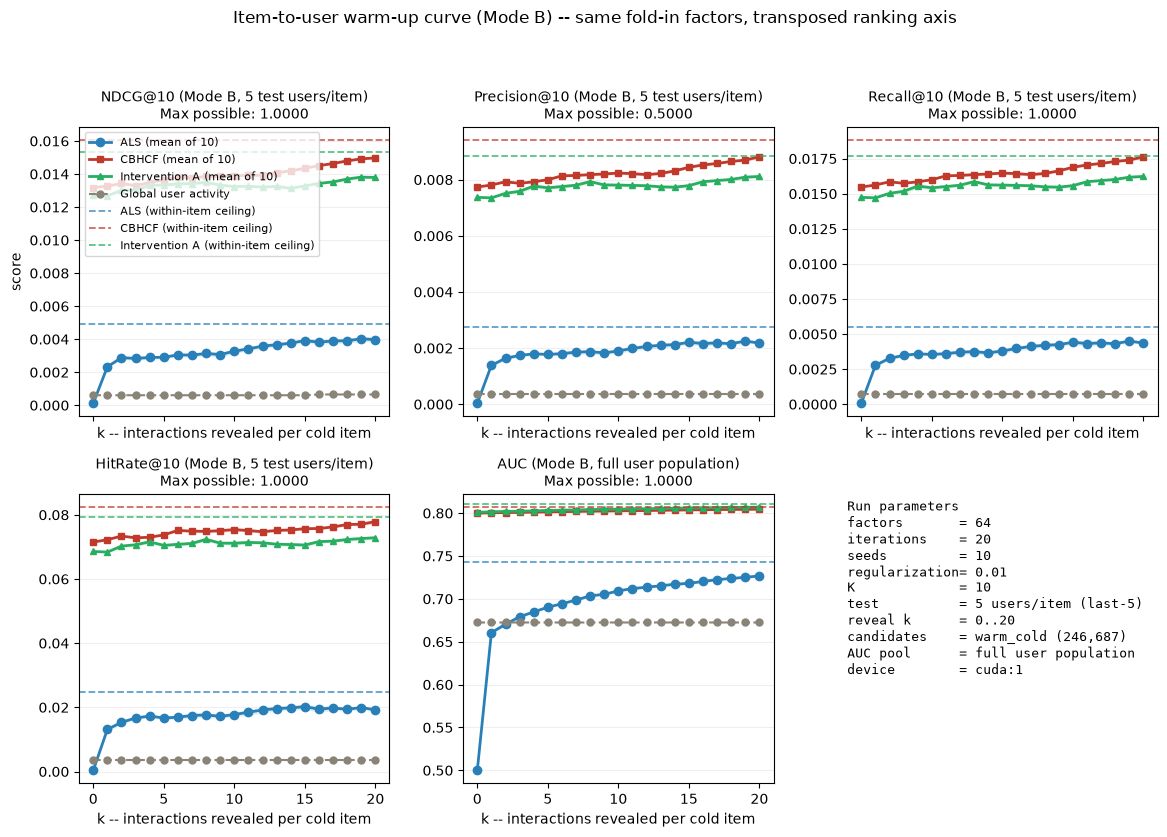

In [24]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS_MODE_B)):
    als_mean = np.array(als_b_curve[metric]["mean"])
    als_std = np.array(als_b_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    if RUN_CBHCF:
        cb_mean = np.array(cbhcf_b_curve[metric]["mean"]); cb_std = np.array(cbhcf_b_curve[metric]["std"])
        ax.plot(K_LEVELS, cb_mean, marker="s", markersize=5, linewidth=2,
                color="#c0392b", label=show_label(f"CBHCF (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, cb_mean - cb_std, cb_mean + cb_std, color="#c0392b", alpha=0.15, linewidth=0)
    if RUN_IA:
        ia_mean = np.array(ia_b_curve[metric]["mean"]); ia_std = np.array(ia_b_curve[metric]["std"])
        ax.plot(K_LEVELS, ia_mean, marker="^", markersize=5, linewidth=2,
                color="#27ae60", label=show_label(f"Intervention A (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, ia_mean - ia_std, ia_mean + ia_std, color="#27ae60", alpha=0.15, linewidth=0)
    ax.plot(K_LEVELS, activity_b_curve[metric]["mean"], marker="o", markersize=5, linewidth=1.5,
            linestyle="--", color="#8A8478", label=show_label("Global user activity"))
    ax.axhline(mode_b_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))
    if RUN_CBHCF:
        ax.axhline(cbhcf_b_ref["mean"][metric], color="#c0392b", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("CBHCF (within-item ceiling)"))
    if RUN_IA:
        ax.axhline(ia_b_ref["mean"][metric], color="#27ae60", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Intervention A (within-item ceiling)"))

    title_line1 = ("AUC (Mode B, full user population)" if metric == "AUC"
                   else f"{metric}@{K_MODE_B} (Mode B, {DOWNSAMPLE_SIZE} test users/item)")
    ax.set_title(f"{title_line1}\nMax possible: {ceiling[metric]:.4f}", fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K_MODE_B),
           ("test", f"{DOWNSAMPLE_SIZE} users/item (last-5)"),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", "full user population"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Item-to-user warm-up curve (Mode B) -- same fold-in factors, transposed ranking axis", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_b.png", dpi=120, bbox_inches="tight")
print("Saved Mode B warm-up curve to warmup_curve_mode_b.png")

## 11. Persist results

The warm-up curves and warm-item reference are the deliverable of this run, but they otherwise live
only in cell outputs / kernel memory -- clearing outputs or restarting the kernel loses them (only
the PNGs and the Popularity caches survive). This dumps everything -- config + every curve +
reference + n_eval + Mode B ceiling -- to a timestamped pickle (exact, for re-plotting) and JSON
(human-readable) under `../outputs/`, so the final run is fully recoverable. To copy the results off
WSL afterwards: `cp ~/699-gpu-bench/outputs/* /mnt/c/699-gpu-bench-outputs/`.

In [25]:
%%time
import json, pickle, datetime

results = {
    "config": {
        "ALS_PARAMS": ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K, "K_LEVELS": K_LEVELS,
        "K_MODE_B": K_MODE_B, "DOWNSAMPLE_SIZE": DOWNSAMPLE_SIZE, "DEVICE": DEVICE, "RUN_POP": RUN_POP,
        "n_users": int(dataset.n_users), "n_items": int(dataset.n_items),
        "n_cold_items": int(len(dataset.cold_item_ids)),
        "test_per_cold_item": int(dataset.test_matrix.nnz / max(len(dataset.cold_item_ids), 1)),
        "auc_min_degree": 25,   # degree-matched AUC pool threshold (reserve degree-matching for AUC)
        "RUN_CBHCF": RUN_CBHCF, "CBHCF_LAMBDA": CBHCF_LAMBDA,
        "CBHCF_FIELD_WEIGHTS": CBHCF_FIELD_WEIGHTS,
        "CBHCF_LAMBDA_PROVENANCE": CBHCF_LAMBDA_PROVENANCE,
        "RUN_IA": RUN_IA, "IA_CONFIG": IA_CFG,
        # Intervention B: fold-in only. `IB_SOURCE` names the export it came from, so a
        # curve here can always be traced back to the generation run that produced it.
        "RUN_IB": RUN_IB, "IB_ARMS": list(IB_ARMS) if RUN_IB else [],
        "IB_CONFIG": ({k: _ib_meta[k] for k in
                       ("N_SELECT", "COLDLLM_TOP_K", "COLDLLM_MODEL", "PROMPT_TAG",
                        "n_cold_items", "results_source")}
                      if RUN_IB and _ib_meta else None),
        "IB_USAGE": "fold-in only; synthetic pairs never entered any fit()",
        "dataset_fingerprint": list(FP),
        "n_cold_val_items": int(len(dataset.cold_val.cold_item_ids)) if dataset.cold_val else 0,
        "ref_train_nnz": int(dataset.ref_train.nnz), "ref_test_nnz": int(dataset.ref_test.nnz),
        # Provider equity (9c). `EQUITY_METRICS_VERSION` is what lets a stored curve be traced to
        # the metric SEMANTICS that produced it -- the dataset fingerprint cannot see a change to
        # what a Gini is computed over, which is exactly how D2/D4 survived unnoticed.
        "EQUITY_METRICS_VERSION": eq.EQUITY_METRICS_VERSION,
        "EQUITY_DISCOUNT": EQUITY_DISCOUNT,
        "EQUITY_DISCOUNTS_REPORTED": list(eq.DEFAULT_DISCOUNTS),
        "EQUITY_USERS": int(len(EQUITY_USERS)),
        "EQUITY_USERS_ARE_ALL": bool(len(EQUITY_USERS) == dataset.n_users),
        "RUN_POP_EQUITY": RUN_POP_EQUITY, "RUN_IB_EQUITY": RUN_IB_EQUITY,
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    },
    # "reference" is now the WITHIN-ITEM ceiling (cold items folded in with all pre-test history on the
    # last-5 test), not the old cross-population warm-item reference.
    "reference": {"als": als_ref, "pop": pop_ref, "cbhcf": cbhcf_ref, "intervention_a": ia_ref},
    "mode_a": {"als_curve": als_curve, "pop_curve": pop_curve, "cbhcf_curve": cbhcf_curve,
               "intervention_a_curve": ia_curve,
               "intervention_b_curves": {a: ib_curves[a] for a in IB_ARMS} if RUN_IB else None,
               "n_eval_per_k": n_eval_per_k,
               "strata": strata, "pop_strata": pop_strata, "cbhcf_strata": cbhcf_strata,
               "intervention_a_strata": ia_strata,
               "bucket_labels": bucket_labels, "bucket_info": bucket_info,
               # Section 9c. Provider equity is a Mode A measurement -- same top-K lists, scored by
               # who supplied the item instead of whether the user wanted it -- so it lives here
               # rather than beside it. `skipped` is persisted deliberately: an arm missing from
               # `curves` must be distinguishable from an arm that scored zero.
               "equity": {"curves": equity_curves, "ceiling": equity_ceiling,
                          "skipped": equity_skipped,
                          "population_sensitivity": population_sensitivity,
                          "n_providers": int(provider_map.n_providers),
                          "provider_field": "content.canonical_creator (author_name -> store)",
                          "provider_stats": provider_stats}},
    "mode_b": {"als_curve": als_b_curve, "activity_curve": activity_b_curve,
               "cbhcf_curve": cbhcf_b_curve, "cbhcf_within_item_ceiling": cbhcf_b_ref,
               "intervention_a_curve": ia_b_curve, "intervention_a_within_item_ceiling": ia_b_ref,
               "n_eval_per_k": n_eval_b_per_k, "ceiling": ceiling, "within_item_ceiling": mode_b_ref},
}

def _jsonable(o):
    """`float(o) if hasattr(o, "__float__")` looks right and is not: a numpy ARRAY has __float__
    but raises "only length-1 arrays can be converted" for size > 1, and every warm-up curve in
    `results` is an array. Arrays go to lists; numpy scalars narrow; anything else stringifies."""
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if hasattr(o, "tolist"):
        return o.tolist()
    return str(o)


os.makedirs("../outputs", exist_ok=True)
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base = f"../outputs/baseline_cf_{stamp}"
# .pkl FIRST, deliberately: it is the lossless copy and it is what the other notebooks read. When
# the JSON encoder raised here previously, the run's results had already survived on disk.
with open(base + ".pkl", "wb") as f:
    pickle.dump(results, f)
with open(base + ".json", "w") as f:
    json.dump(results, f, indent=2, default=_jsonable)
print(f"Saved results to {base}.pkl and {base}.json")
print(f"  seeds={N_SEEDS}  iters={ALS_PARAMS['iterations']}  factors={ALS_PARAMS['factors']}  "
      f"K={K}  K_LEVELS={K_LEVELS[0]}..{K_LEVELS[-1]}  device={DEVICE}")

# ---- Consolidated results recap (headline top-K first; AUC is degree-matched, reported last) ----
print("\n" + "=" * 78)
print("RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)")
print("=" * 78)
lastk = len(K_LEVELS) - 1
print(f"\nMode A -- user-centric (K={K}):")
print(f"  {'metric':<12}{'Pop k=0':>10}{'ALS k=0':>10}{'CB k=0':>10}{'IA k=0':>10}"
      f"{'Pop k=20':>11}{'ALS k=20':>11}{'CB k=20':>11}{'IA k=20':>11}"
      f"{'Pop ceil':>11}{'ALS ceil':>11}{'CB ceil':>11}{'IA ceil':>11}")
_nan = float("nan")
for m in METRICS:
    row = (f"  {m:<12}"
           f"{(pop_curve[m]['mean'][0] if RUN_POP else _nan):>10.4f}"
           f"{als_curve[m]['mean'][0]:>10.4f}"
           f"{(cbhcf_curve[m]['mean'][0] if RUN_CBHCF else _nan):>10.4f}"
           f"{(ia_curve[m]['mean'][0] if RUN_IA else _nan):>10.4f}"
           f"{(pop_curve[m]['mean'][lastk] if RUN_POP else _nan):>11.4f}"
           f"{als_curve[m]['mean'][lastk]:>11.4f}"
           f"{(cbhcf_curve[m]['mean'][lastk] if RUN_CBHCF else _nan):>11.4f}"
           f"{(ia_curve[m]['mean'][lastk] if RUN_IA else _nan):>11.4f}"
           f"{(pop_ref['mean'][m] if RUN_POP else _nan):>11.4f}"
           f"{als_ref['mean'][m]:>11.4f}"
           f"{(cbhcf_ref['mean'][m] if RUN_CBHCF else _nan):>11.4f}"
           f"{(ia_ref['mean'][m] if RUN_IA else _nan):>11.4f}")
    print(row)

print(f"\nMode A tail breakdown -- within-item ceiling by degree tercile (K={K}):")
for b in range(len(bucket_labels)):
    bi, s = bucket_info[b], strata[b]
    print(f"  {bucket_labels[b]:<6} deg {bi['deg_min']}-{bi['deg_max']} (med {bi['deg_median']}, "
          f"{bi['n_items']:,} items):  HitRate={s['hitrate']:.4f}  NDCG={s['ndcg']:.4f}")

print(f"\nMode B -- item-to-user (K={K_MODE_B}; AUC full user population):")
print(f"  {'metric':<12}{'Act k=20':>11}{'ALS k=20':>11}{'CB k=20':>11}{'IA k=20':>11}"
      f"{'ALS ceil':>11}{'CB ceil':>11}{'IA ceil':>11}{'max':>9}")
for m in METRICS_MODE_B:
    print(f"  {m:<12}{activity_b_curve[m]['mean'][lastk]:>11.4f}{als_b_curve[m]['mean'][lastk]:>11.4f}"
          f"{(cbhcf_b_curve[m]['mean'][lastk] if RUN_CBHCF else _nan):>11.4f}"
          f"{(ia_b_curve[m]['mean'][lastk] if RUN_IA else _nan):>11.4f}"
          f"{mode_b_ref['mean'][m]:>11.4f}"
          f"{(cbhcf_b_ref['mean'][m] if RUN_CBHCF else _nan):>11.4f}"
          f"{(ia_b_ref['mean'][m] if RUN_IA else _nan):>11.4f}{ceiling[m]:>9.4f}")
print("=" * 78)

# The comparison this notebook exists to make. Both hybrids wrap the SAME ten ALS fits and differ
# only in how an item's own text is represented, so this difference is attributable to that and
# nothing else. cold_val predicted TF-IDF ahead by ~20% on NDCG while every encoder led on AUC --
# these are the reported (cold TEST, 10-seed) numbers for the same question.
if RUN_CBHCF and RUN_IA:
    print("\nCBHCF (TF-IDF prose) vs Intervention A (arctic embeddings), same ALS seeds:")
    print(f"  {'metric':<12}{'CBHCF k=0':>12}{'IA k=0':>12}{'delta':>9}"
          f"{'CBHCF ceil':>13}{'IA ceil':>11}{'delta':>9}")
    for m in METRICS:
        c0, i0 = cbhcf_curve[m]["mean"][0], ia_curve[m]["mean"][0]
        cc, ic = cbhcf_ref["mean"][m], ia_ref["mean"][m]
        d0 = (i0 / c0 - 1) * 100 if c0 else _nan
        dc = (ic / cc - 1) * 100 if cc else _nan
        print(f"  {m:<12}{c0:>12.4f}{i0:>12.4f}{d0:>8.1f}%{cc:>13.4f}{ic:>11.4f}{dc:>8.1f}%")
    print(f"  (cold_val predicted: CBHCF {STEEL_CFG['cbhcf']['coldval_objective']:.5f} vs "
          f"Intervention A {IA_CFG['coldval_objective']:.5f})")

# ---- Provider equity (9c) ------------------------------------------------------------------
# The provider-side companion to everything above. Read ACROSS arms at matched k, not the absolute
# level: all arms share the same ten ALS fits, so a difference is the item representation. Gini
# levels are comparable across arms within a discount, never across discounts.
print(f"\nProvider exposure equity -- {EQUITY_DISCOUNT} discount, "
      f"{'all ' + format(dataset.n_users, ',') if EQUITY_USERS is None else format(len(EQUITY_USERS), ',')}"
      f" users, {provider_map.n_providers:,} providers (equity_metrics v{eq.EQUITY_METRICS_VERSION}):")
print(f"  {'arm':<16}{'Gini k=0':>10}{'Gini k=20':>11}{'Gini ceil':>11}"
      f"{'cold share k=20':>17}{'cold ratio k=20':>17}{'providers <1x':>15}")
for _label, _cur in equity_curves.items():
    _c = _cur[EQUITY_DISCOUNT]
    _ceil = equity_ceiling.get(_label)
    print(f"  {_label:<16}{_c['gini']['mean'][0]:>10.4f}{_c['gini']['mean'][lastk]:>11.4f}"
          f"{(format(_ceil[EQUITY_DISCOUNT]['gini']['mean'][0], '.4f') if _ceil else '--'):>11}"
          f"{_c['cold_exposure_share']['mean'][lastk]:>17.5f}"
          f"{_c['cold_ratio.exposure_weighted_mean']['mean'][lastk]:>17.3f}"
          f"{_c['cold_ratio.frac_below_1']['mean'][lastk]:>15.3f}")
if equity_skipped:
    print("  NOT measured: " + "; ".join(f"{a} ({why})" for a, why in equity_skipped.items()))
print("=" * 78)

Saved results to ../outputs/baseline_cf_20260811_103923.pkl and ../outputs/baseline_cf_20260811_103923.json
  seeds=10  iters=20  factors=64  K=100  K_LEVELS=0..20  device=cuda:1

RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)

Mode A -- user-centric (K=100):
  metric         Pop k=0   ALS k=0    CB k=0    IA k=0   Pop k=20   ALS k=20    CB k=20    IA k=20   Pop ceil   ALS ceil    CB ceil    IA ceil
  NDCG            0.0000    0.0000    0.0419    0.0355     0.0000     0.0009     0.0439     0.0382     0.0012     0.0053     0.0466     0.0419
  Precision       0.0000    0.0000    0.0016    0.0013     0.0000     0.0001     0.0017     0.0014     0.0001     0.0003     0.0018     0.0016
  Recall          0.0000    0.0000    0.1411    0.1165     0.0000     0.0048     0.1481     0.1252     0.0055     0.0252     0.1572     0.1384
  HitRate         0.0000    0.0000    0.1490    0.1220     0.0000     0.0056     0.1573     0.1317     0.0062     0.0287     0.1

## 12. Summary

- **Objective:** isolate the effect that a given retrieval method has on how quickly an item
  becomes recommendable as it accumulates interaction history — built so that future
  interventions (content embeddings, improved content embeddings, LLM-simulated interactions)
  can be slotted in and compared against this same baseline on equal footing.
- **The controlling principle:** user preferences are fit once (Section 5b, on `ref_train`)
  and reused identically everywhere in this notebook. Only the item's own representation
  changes as it accumulates revealed history.
- **Modularization:** the mechanism now lives in `load.py`/`pop.py`/`cf.py`/`eval.py` behind a
  shared `protocol.RetrievalModel` contract, so a future retrieval method plugs into the exact
  same `eval.sweep_mode_a_cached()`/`sweep_item_to_user_gpu()` calls used above — no new
  evaluation code required.
- **Provider equity (9c) is the provider-side companion, not a second accuracy metric.** Sections
  9–11 ask whether a cold *item* became retrievable; 9c asks whose items get the impressions, and
  whether an intervention that helps cold items also moves exposure toward *their* providers or
  simply reshuffles the head. It reuses the same recommendation lists — `equity_metrics` consumes
  `eval.sweep_mode_a_cached`'s `on_recs` hook, or re-runs the same cached retrieval over the whole
  user population — so no separate evaluation path exists for it either.
  - **Read it across arms at matched `k`.** Every arm wraps the same ten ALS fits, so a difference
    is attributable to the item representation. The absolute Gini is mostly a fact about the
    Amazon Books catalogue, and Gini levels are comparable across arms *within* a discount but
    never across discounts — concentrating the exposure mass raises Gini by construction.
  - **Caveats that belong in the writeup, not in a footnote.** `store` is an imperfect stand-in
    for authorship where `author_name` is empty; surname-first names still split into two
    entities (`bench_28` pins this); merit share is estimated from a sparse binary held-out
    signal; and a deterministic top-K amplifies near-ties into large exposure gaps, so some
    measured concentration is the serving rule rather than the model. The seed-stability readout
    in 9c bounds that last one; the principled fix — a stochastic ranking policy evaluated on
    expected exposure — would change what is being served and is a separate experiment.